In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/figure2/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [2]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [21]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset,species
sample,,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public,Homo sapiens
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public,Homo sapiens
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house,Homo sapiens
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public,Homo sapiens
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house,Homo sapiens
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house,Homo sapiens
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house,Homo sapiens
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public,Homo sapiens
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house,Homo sapiens


In [3]:
adata_new=sc.read('human_cochlea_annotation_add_40000genes.h5ad')

In [5]:
#subset cochlear epithelium cell-type cells
# extract cochlear epirhelium cell types 
adata_coe=adata_new[adata_new.obs['cell_type_final'].isin(['Claudius/Inner-Outer_sulcus_cells','CoE_Lateral','CoE_Medial',
                                                   'CoE_prosensory','Cochlear_HCs','Deiters_cells','Inner_border-phalangeal/Hensen_cells',
                                                  'Interdental_cells','Pillar_cells','SCs']
    
)]
adata_coe

View of AnnData object with n_obs × n_vars = 8113 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'species', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'cell_type_final', 'low_ncounts', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'is_doublet_scrub', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_res2.0'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'm

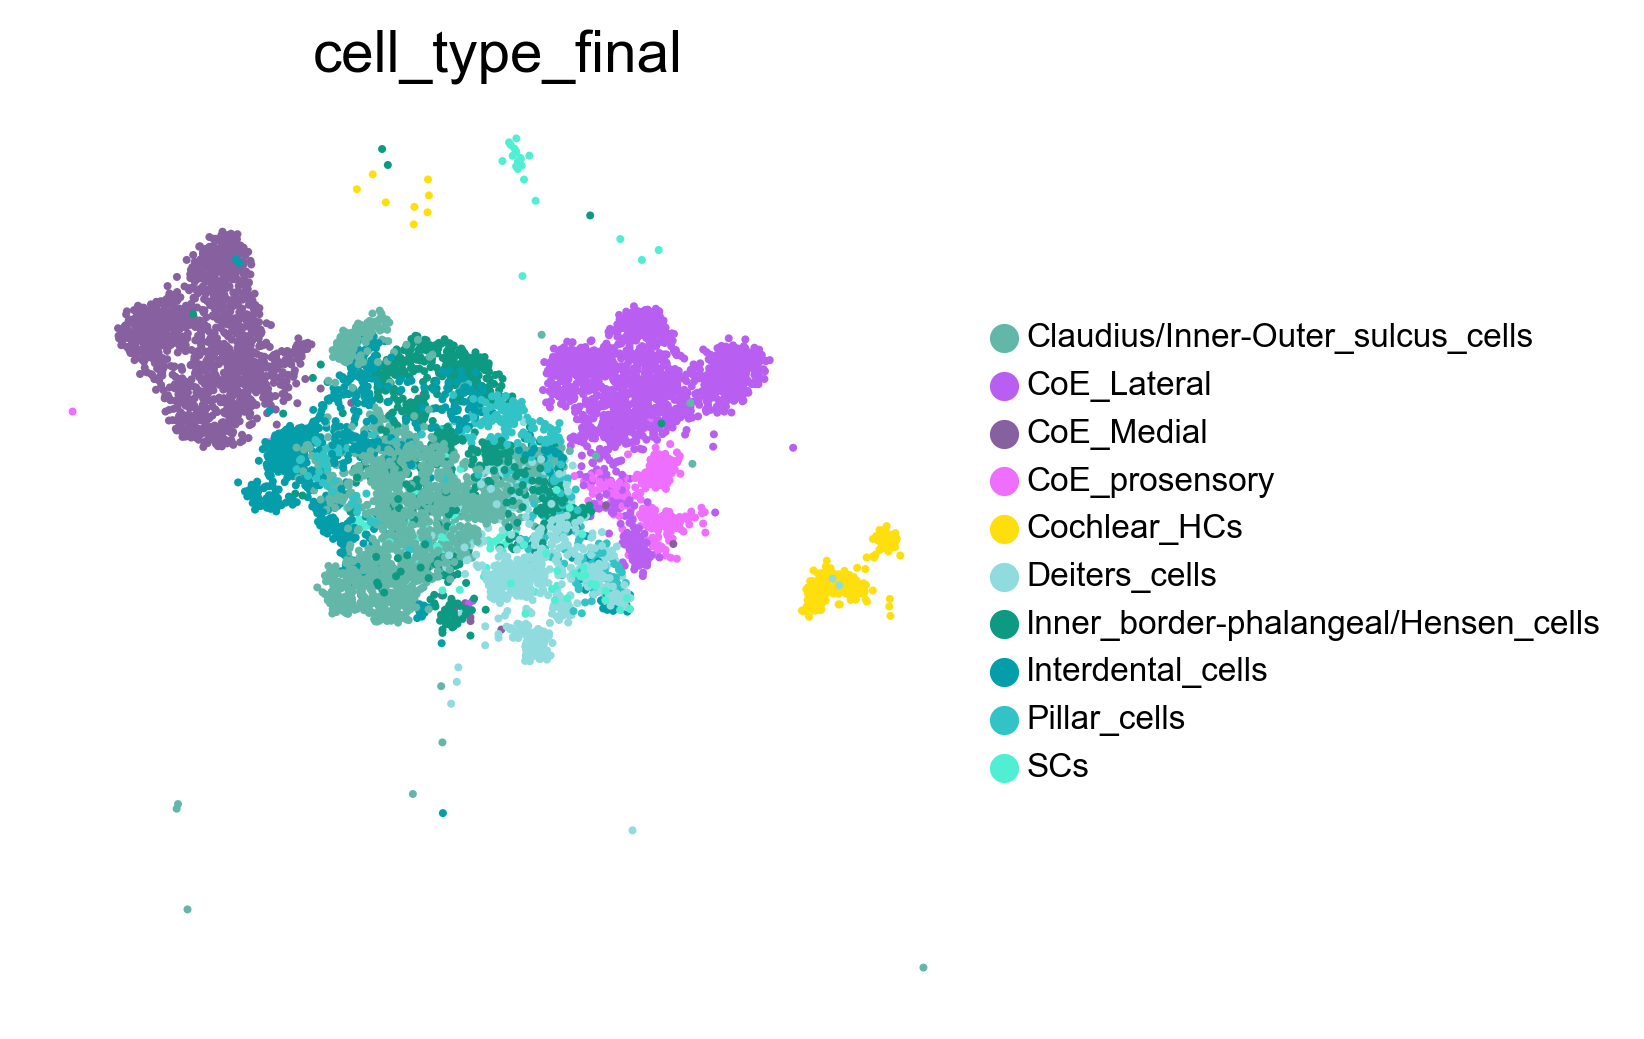

In [10]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_coe, color=['cell_type_final'], wspace=0.5,ncols=1,save='_human_prenatal_coe.pdf',
           legend_fontsize=8,) #legend_loc='on data',

In [11]:
palette2={
             "Interdental_cells": "#2cb5b1",
              "Pillar_cells": "#e54880",
              "Deiters_cells": "#9cb219",
              "Inner_border-phalangeal/Hensen_cells": "#d39c62",
              "Claudius/Inner-Outer_sulcus_cells": "#b55f41",
              "SCs": "#586fdd",
              "Cochlear_HCs": "#ffde0d",
             "CoE_Lateral": "#b85ff2", 
               "CoE_Medial": "#8760a0",
               "CoE_prosensory": "#ed6eff",   
            }

In [12]:
#set to age bins
cut_labels_4 = ['< 14', '< 18','< 26', ]
cut_bins = [0, 14,18,26 ]

adata_coe.obs["age_bins"] = pd.cut(adata_coe.obs["gw"], bins=cut_bins, labels=cut_labels_4).astype("str")
adata_coe.obs["age_bins"] = pd.Categorical(adata_coe.obs["age_bins"], categories=cut_labels_4, ordered=True)
adata_coe.obs["age_bins"]

9.5gw_AAACCCAAGCTGCCTG     < 14
9.5gw_AAACGCTCACCCGTAG     < 14
9.5gw_AAAGAACCAAACACGG     < 14
9.5gw_AAAGAACGTAACGTTC     < 14
9.5gw_AAAGTCCAGAGGCTGT     < 14
                           ... 
26+3gw_TCACTATTCTACGGGC    < 26
26+3gw_TCCCATGAGGTGCCAA    < 26
26+3gw_TCTTCCTTCGTGGGAA    < 26
26+3gw_TGTCCACCAGGTACGA    < 26
26+3gw_TTGGGTACAAGTGGGT    < 26
Name: age_bins, Length: 8113, dtype: category
Categories (3, object): ['< 14' < '< 18' < '< 26']

In [13]:
# Convert covariate to continous
adata_coe.obs['age_bins'] = adata_coe.obs['age_bins'].cat.codes
adata_coe.obs['age_bins']
adata_coe.obs.groupby(['gw','sample_id','age_bins']).apply(len)

9.5gw_AAACCCAAGCTGCCTG     0
9.5gw_AAACGCTCACCCGTAG     0
9.5gw_AAAGAACCAAACACGG     0
9.5gw_AAAGAACGTAACGTTC     0
9.5gw_AAAGTCCAGAGGCTGT     0
                          ..
26+3gw_TCACTATTCTACGGGC    2
26+3gw_TCCCATGAGGTGCCAA    2
26+3gw_TCTTCCTTCGTGGGAA    2
26+3gw_TGTCCACCAGGTACGA    2
26+3gw_TTGGGTACAAGTGGGT    2
Name: age_bins, Length: 8113, dtype: int8

C:\Users\Dell\AppData\Local\Temp\ipykernel_44936\2169444871.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_coe.obs.groupby(['gw','sample_id','age_bins']).apply(len)
C:\Users\Dell\AppData\Local\Temp\ipykernel_44936\2169444871.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  adata_coe.obs.groupby(['gw','sample_id','age_bins']).apply(len)


gw  sample_id  age_bins
9   gw9        0            692
11  gw11       0            780
14  gw14       0           1887
15  gw15       1            248
16  gw16       1            910
17  gw17_1     1            152
    gw17_2     1            314
    gw17_3     1            169
18  gw18       1            273
20  gw20       2            290
22  gw22_1     2            386
    gw22_2     2            678
23  gw23       2            630
25  gw25       2            684
26  gw26       2             20
dtype: int64

In [15]:
def Barplot(which_var, adata, var='clusters', height=3, color = False):
    plotdata = pd.crosstab(adata.obs[var], adata.obs[which_var], normalize='index') * 100
    if 'category' in plotdata.index.dtype.name:
        plotdata.index.reorder_categories(adata.obs[var].cat.categories[::-1])

    if not color:
        ax1 = plotdata.plot.barh(stacked = True, edgecolor = 'none', zorder = 3, figsize = (6,height), fontsize = 14, grid = False)
    else:
        ax1 = plotdata.plot.barh(stacked = True, edgecolor = 'none', zorder = 3, figsize = (6,height), fontsize = 14, grid = False, color = color)
    ax1.set_title(which_var+' %')
    ax1.set_ylabel(var)
    horiz_offset = 1
    vert_offset = 1.
    ax1 = ax1.legend(bbox_to_anchor = (horiz_offset, vert_offset))
#     ax1.figure.savefig(str(sc.settings.figdir)+'/barplot_'+var+'_proportions_'+which_var+'.pdf', bbox_inches='tight',
#                        dpi=300, orientation='landscape', format= 'pdf', optimize=True)

In [19]:
palette={"Erythrocytes": "#9a9ae8", #Circulating cells
             "Macrophages": "#5757dd",
             "CCs": "#45457f",
              "Tympanic_border_cells": "#806114",# Surrounding structures
            "Reissner_membrane": "#e0a31b",
             "pre-Osteoblasts": "#b59a5d",
             "pre-Osteocytes": "#726750",
             "Osteoblasts": "#c6b691",
             "Osteocytes": "#edc264",
             "SS": "#9e6e04",

             "Endothelial": "#ef7b75",# Lateral wall
             "Pericytes": "#992b28",
             "Smooth_Muscle_Cells": "#cc9997",
             "Marginal_stria": "#f23833",
             "Intermediate_stria": "#c61612",
             "Basal_stria": "#ef7048",
             "Spindle/Root_cells": "#930300",
             "Fibrocytes": "#efb4a8",

             "Interdental_cells": "#049eaa",# Supporting cells
              "Pillar_cells": "#32c3c6",
              "Deiters_cells": "#90dbdd",
              "Inner_border-phalangeal/Hensen_cells": "#0d9982",
              "Claudius/Inner-Outer_sulcus_cells": "#63b7a9",
              "SCs": "#50efd4",

              "Cochlear_HCs": "#ffde0d",# Hair cells
               "Vestibular_HCs": "#8e7c20",
             
             "Vestibular_SCs": "#efd6bb", # Vestibular
               "Vestibular_Epithelial_cells": "#f2902f",
             "Vestibular_Roof_cells": "#c4b470",
               "Vestibular_Dark_cells": "#abb21b",

             "CoE_Lateral": "#b85ff2", # early cochlear domain
               "CoE_Medial": "#8760a0",
             "CoE_Roof_cells": "#b597c9",
               "CoE_prosensory": "#ed6eff",

             "SGNs": "#89d3a4",# Neurons
               "VGNs": "#025921",
             "GCs": "#8ce264",# Glial cells

              "Mesenchymal": "#eaea78",
             "Chondrocytes": "#bcbc86",
               "Melanocytes": "#c68d8d",
       
            
            }

#### FIGURE 2a
##### cell-type composition

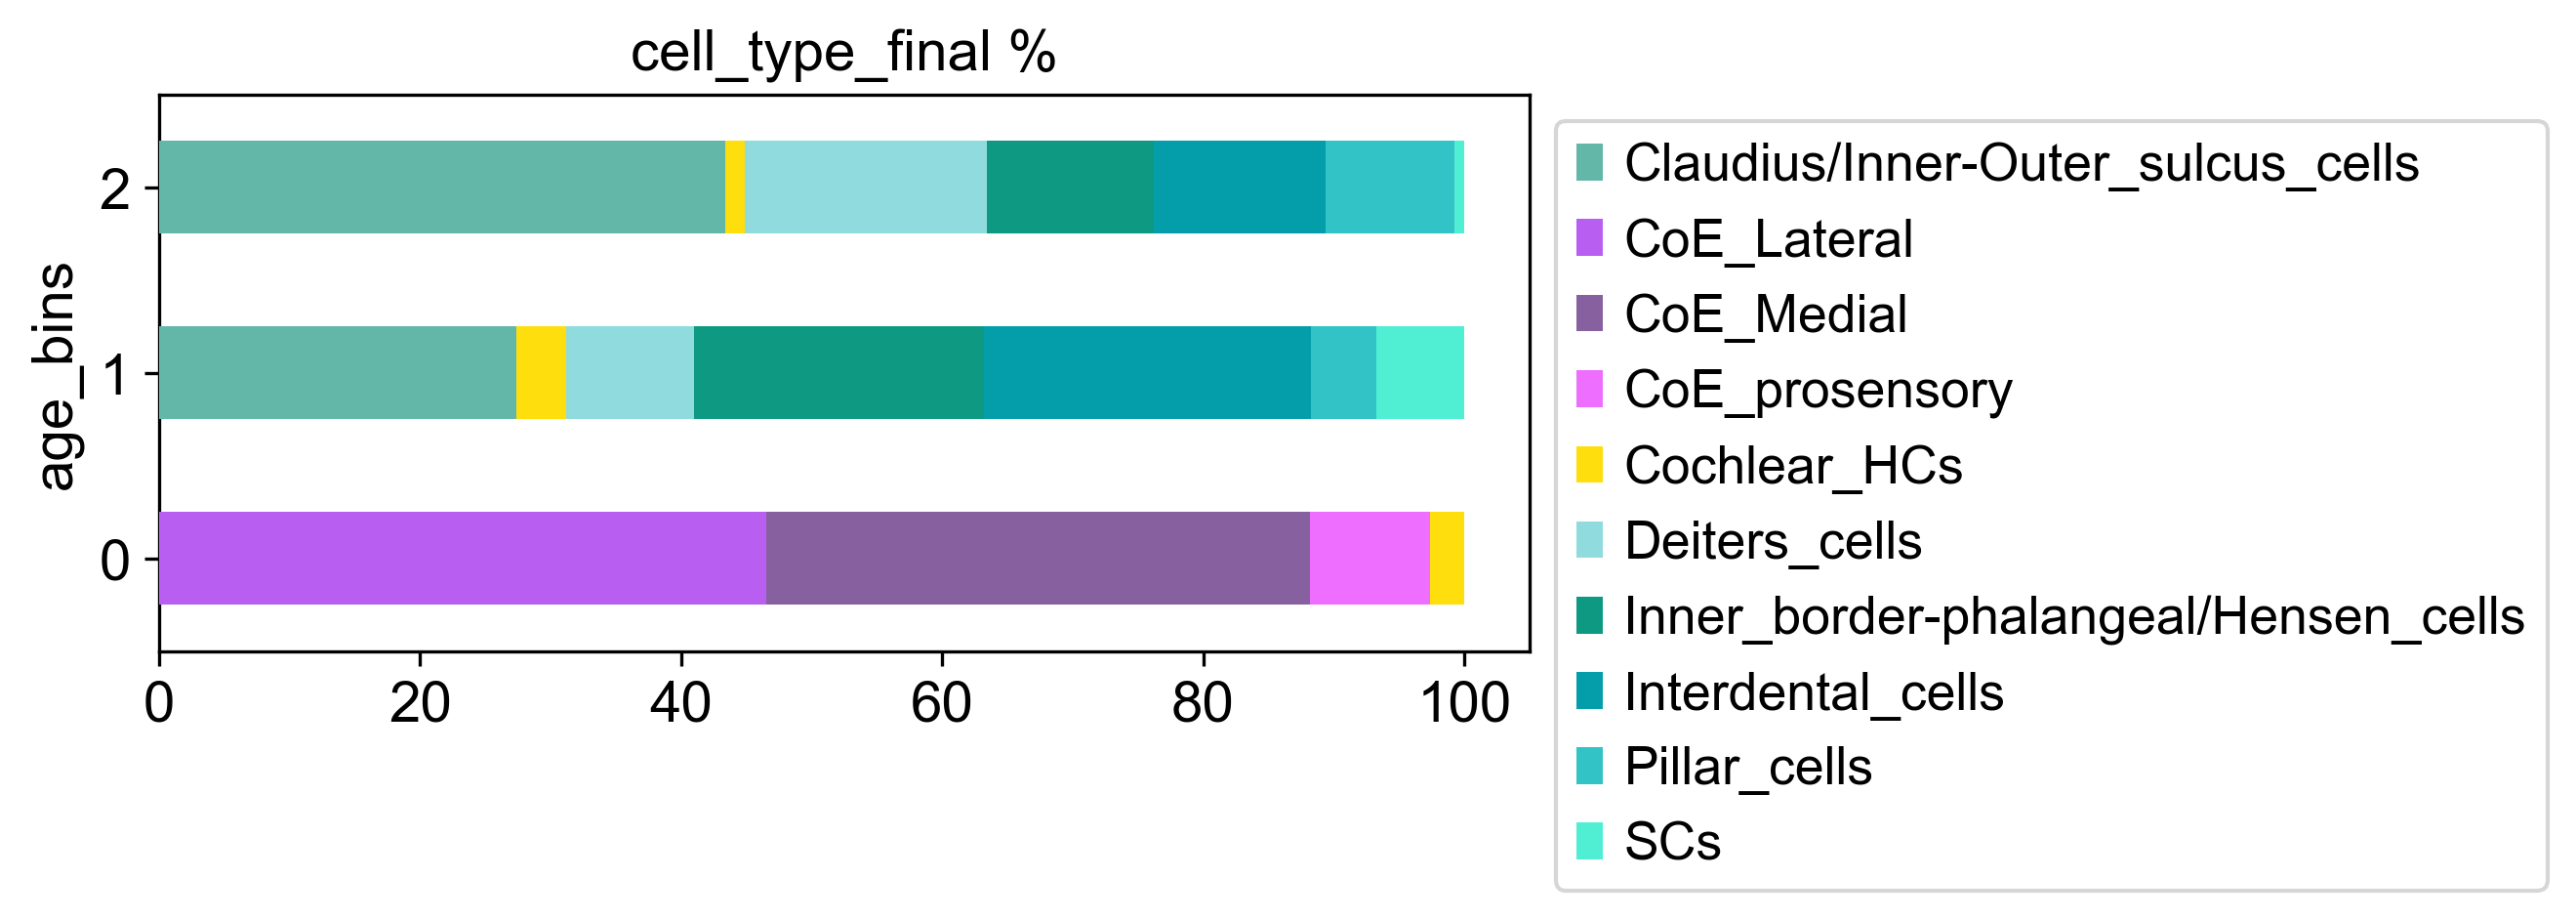

In [22]:
sc.set_figure_params(frameon=False,dpi=150,dpi_save=600)
Barplot('cell_type_final', adata_coe, var='age_bins', height=2.5,color=palette,
       )
plt.savefig (data_dir+"figures/figure2/Barplot_cell_type_porprotion_age_bins_coe.pdf", format="pdf", bbox_inches="tight")

#### FIGURE 2c
##### coe umap embeddings

In [23]:
adata_sub=sc.read('human_coe_sub_for_trajectory_analysis_v4.h5ad')
adata_sub

AnnData object with n_obs × n_vars = 2388 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'leiden_res1.0', 'is_doublet_scrub', 'leiden_res1.1', 'leiden_res4.0', 'leiden_res2.0', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_scanvi_3.0', 'leiden_scanvi_4.0', 'cell_type_final', 'cell_type_final_v2', 'scANVI_res2.0', 'cell_type_final_v4'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 

In [24]:
cluster_annotation = {
 'FGF20+SULF1+Medial_PSD': 'FGFR3+PROX1+Lateral_PSD',
     'TBX2+MEIS2+Early_PSD': 'TBX2+MEIS2+Early_PSD',
     'FGFR3+PROX1+Lateral_PSD': 'FGF20+SULF1+Medial_PSD',
     'Outer_HC': 'Outer_HC',
     'Inner_HC': 'Inner_HC',
     'LGR6+TMPRSS3+_PC': 'LGR6+TMPRSS3+_PC',
    'LGR6+TMPRSS3+_PC': 'LGR6+TMPRSS3+_PC',
    'PPP1R2+HIST1H2AC+_PC': 'PPP1R2+HIST1H2AC+_PC',
     'ISL1+ST3GAL1+IBC_IPhC': 'ISL1+ST3GAL1+IBC_IPhC',
    'FOXG1+RELN+IBC_IPhC': 'FOXG1+RELN+IBC_IPhC',
     'SPOCK1+PEX5L+IBC_IPhC': 'SPOCK1+PEX5L+IBC_IPhC',
    'SLC24A3+ZBTB20+IBC_IPhC': 'SLC24A3+ZBTB20+IBC_IPhC',
     'SERPINE2+JAG1+DC': 'SERPINE2+JAG1+DC',
    'PTGDS+CEMIP+DC': 'PTGDS+CEMIP+DC',
     'EGFR+ELMO1+HEC': 'EGFR+ELMO1+HEC',
    'FST+AFF3+HEC': 'FST+AFF3+HEC',
}
adata_sub.obs['cell_type_final_v4'] = adata_sub.obs['cell_type_final_v4'].map(cluster_annotation).astype('category')

In [25]:
cluster_annotation = {
    'FGFR3+PROX1+Lateral_PSD': 'CoE_prosensory',
    'FGF20+SULF1+Medial_PSD':'CoE_prosensory',
     'TBX2+MEIS2+Early_PSD': 'CoE_prosensory',
     'Outer_HC': 'Cochlear_HCs',
     'Inner_HC': 'Cochlear_HCs',
     'LGR6+TMPRSS3+_PC': 'Pillar_cells',
    'LGR6+TMPRSS3+_PC': 'Pillar_cells',
    'PPP1R2+HIST1H2AC+_PC': 'Pillar_cells',
     'ISL1+ST3GAL1+IBC_IPhC': 'Inner_border-phalangeal_cells',
    'FOXG1+RELN+IBC_IPhC': 'Inner_border-phalangeal_cells',
     'SPOCK1+PEX5L+IBC_IPhC': 'Inner_border-phalangeal_cells',
    'SLC24A3+ZBTB20+IBC_IPhC': 'Inner_border-phalangeal_cells',
     'SERPINE2+JAG1+DC': 'Deiters_cells',
    'PTGDS+CEMIP+DC': 'Deiters_cells',
     'EGFR+ELMO1+HEC': 'Hensen_cells',
    'FST+AFF3+HEC': 'Hensen_cells',
}
adata_sub.obs['cell_type_final_v3'] = adata_sub.obs['cell_type_final_v4'].map(cluster_annotation).astype('category')

In [26]:
cluster_annotation = {
    'FGFR3+PROX1+Lateral_PSD': 'Lateral_PSD',
    'FGF20+SULF1+Medial_PSD':'Medial_PSD',
     'TBX2+MEIS2+Early_PSD': 'Early_PSD',
     'Outer_HC': 'Cochlear_HCs',
     'Inner_HC': 'Cochlear_HCs',
     'LGR6+TMPRSS3+_PC': 'Pillar_cells',
    'LGR6+TMPRSS3+_PC': 'Pillar_cells',
    'PPP1R2+HIST1H2AC+_PC': 'Pillar_cells',
     'ISL1+ST3GAL1+IBC_IPhC': 'Inner_border-phalangeal_cells',
    'FOXG1+RELN+IBC_IPhC': 'Inner_border-phalangeal_cells',
     'SPOCK1+PEX5L+IBC_IPhC': 'Inner_border-phalangeal_cells',
    'SLC24A3+ZBTB20+IBC_IPhC': 'Inner_border-phalangeal_cells',
     'SERPINE2+JAG1+DC': 'Deiters_cells',
    'PTGDS+CEMIP+DC': 'Deiters_cells',
     'EGFR+ELMO1+HEC': 'Hensen_cells',
    'FST+AFF3+HEC': 'Hensen_cells',
}
adata_sub.obs['cell_type_final_v5'] = adata_sub.obs['cell_type_final_v4'].map(cluster_annotation).astype('category')

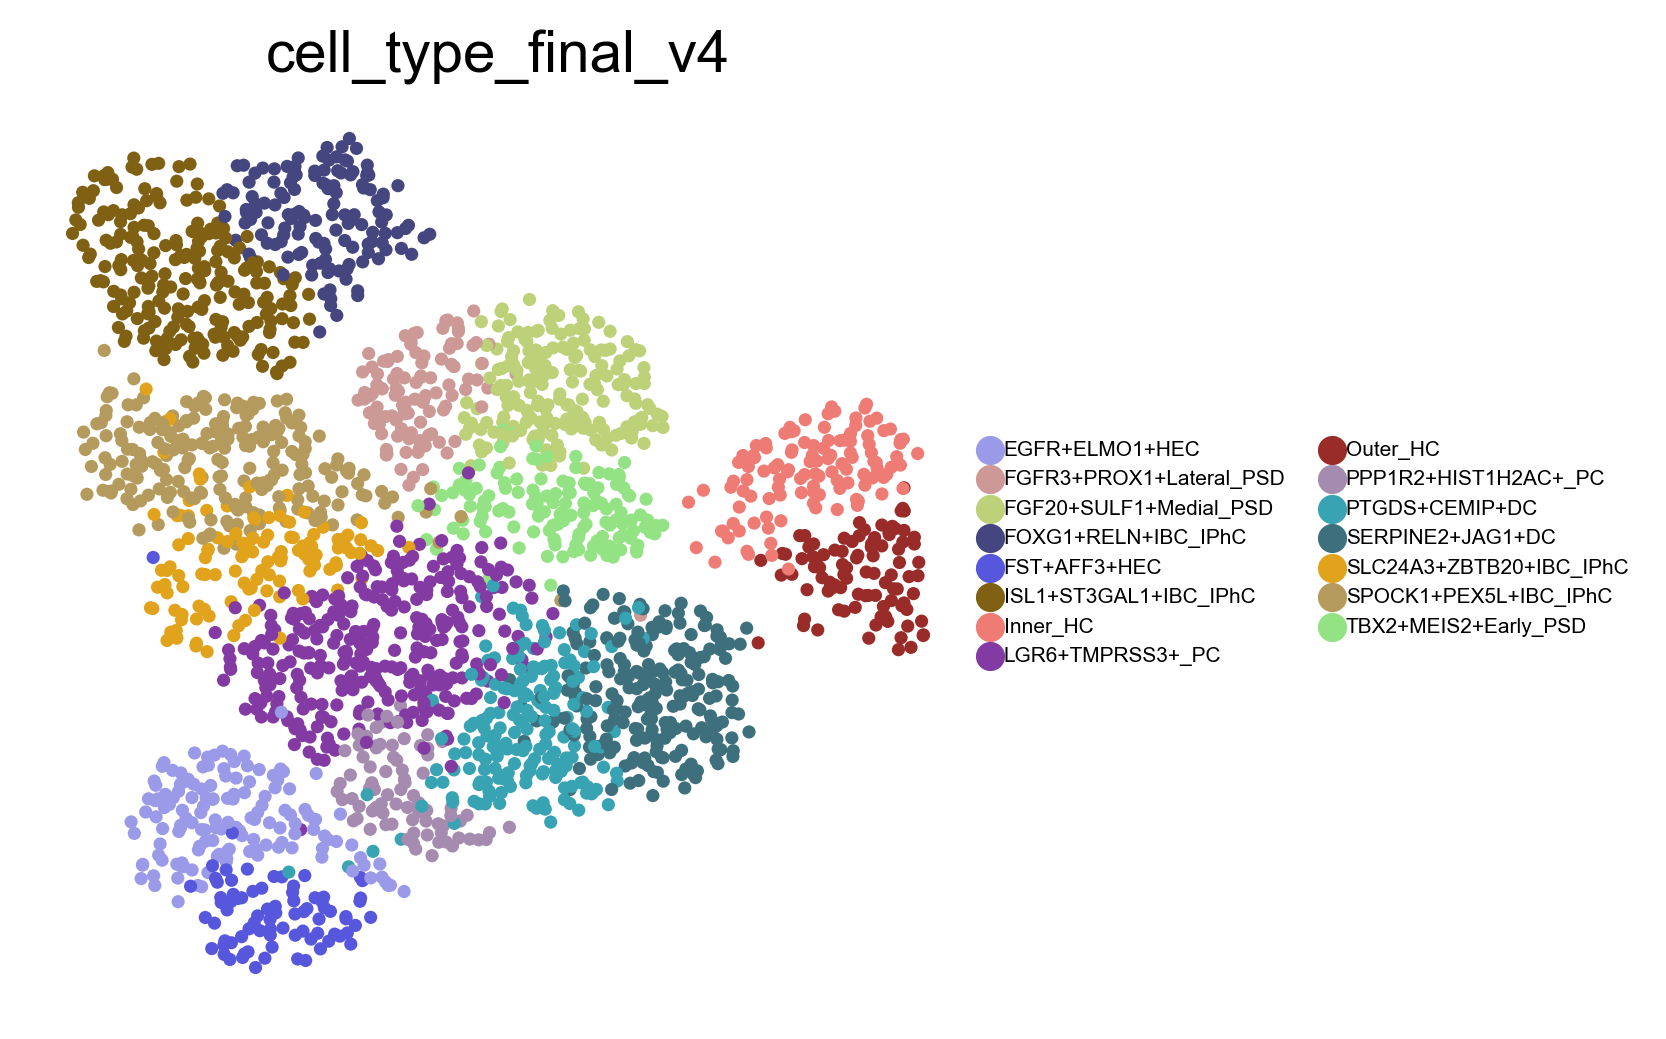

In [28]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(
    adata_sub,legend_fontsize=5,
    color="cell_type_final_v4",
    palette={"EGFR+ELMO1+HEC": "#9a9ae8", #Circulating cells
             "FST+AFF3+HEC": "#5757dd",
             "FOXG1+RELN+IBC_IPhC": "#45457f",

              "ISL1+ST3GAL1+IBC_IPhC": "#806114",# Surrounding structures
            "SLC24A3+ZBTB20+IBC_IPhC": "#e0a31b",
             "SPOCK1+PEX5L+IBC_IPhC": "#b59a5d",
             "LGR6+TMPRSS3+_PC": "#843aa3",
             "PPP1R2+HIST1H2AC+_PC": "#a48baf",
             "PTGDS+CEMIP+DC": "#38a3b2",
             "SERPINE2+JAG1+DC": "#3d707c",

             "Inner_HC": "#ef7b75",# Lateral wall
             "Outer_HC": "#992b28",
             "FGFR3+PROX1+Lateral_PSD": "#cc9997",
             "FGF20+SULF1+Medial_PSD": "#bdd178",
             "TBX2+MEIS2+Early_PSD": "#93e283",
             
            
            },


    size=40,


    
)#legend_loc='on data',

#### FIGURE 2d/e/f/g
##### Monocle2 trajevtory analysis in R 

In [31]:
adata_coe_raw=adata_new[adata_sub.obs.index]
adata_coe_raw

View of AnnData object with n_obs × n_vars = 2388 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'species', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'cell_type_final', 'low_ncounts', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'is_doublet_scrub', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_res2.0'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'm

In [32]:
adata_coe_raw.obs['cell_type_final_v4']=adata_sub.obs['cell_type_final_v4']

C:\Users\Dell\AppData\Local\Temp\ipykernel_44936\4041807528.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_coe_raw.obs['cell_type_final_v4']=adata_sub.obs['cell_type_final_v4']


In [34]:
adata_coe_raw.obsm['X_pca']=adata_sub.obsm['X_pca']
adata_coe_raw.obsm['X_scANVI']=adata_sub.obsm['X_scANVI']
adata_coe_raw.obsm['X_scVI']=adata_sub.obsm['X_scVI']
adata_coe_raw.obsm['X_umap']=adata_sub.obsm['X_umap']

In [36]:
#subset outer compartment of cochlear epithelium

adata_new_v2_outer=adata_coe_raw[adata_coe_raw.obs['cell_type_final_v4'].isin(['EGFR+ELMO1+HEC','FST+AFF3+HEC',
                                                                                               'LGR6+TMPRSS3+_PC','PPP1R2+HIST1H2AC+_PC',
                                                        'FGFR3+PROX1+Lateral_PSD','Outer_HC',
                                                   'PTGDS+CEMIP+DC','SERPINE2+JAG1+DC',
                                                           ]
    
)] #'TBX2+MEIS2+Early_PSD',
adata_new_v2_outer

View of AnnData object with n_obs × n_vars = 1236 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'species', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'cell_type_final', 'low_ncounts', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'is_doublet_scrub', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_res2.0', 'cell_type_final_v4'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', '

In [37]:
#subset inner compartment of cochlear epithelium

adata_new_v2_inner=adata_coe_raw[adata_coe_raw.obs['cell_type_final_v4'].isin(['FGF20+SULF1+Medial_PSD',
                                                        'FOXG1+RELN+IBC_IPhC','ISL1+ST3GAL1+IBC_IPhC','Inner_HC',
                                                   'SLC24A3+ZBTB20+IBC_IPhC','SPOCK1+PEX5L+IBC_IPhC',
                                                           ]
    
)] #'TBX2+MEIS2+Early_PSD',
adata_new_v2_inner

View of AnnData object with n_obs × n_vars = 1014 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'species', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'cell_type_final', 'low_ncounts', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'is_doublet_scrub', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_res2.0', 'cell_type_final_v4'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', '

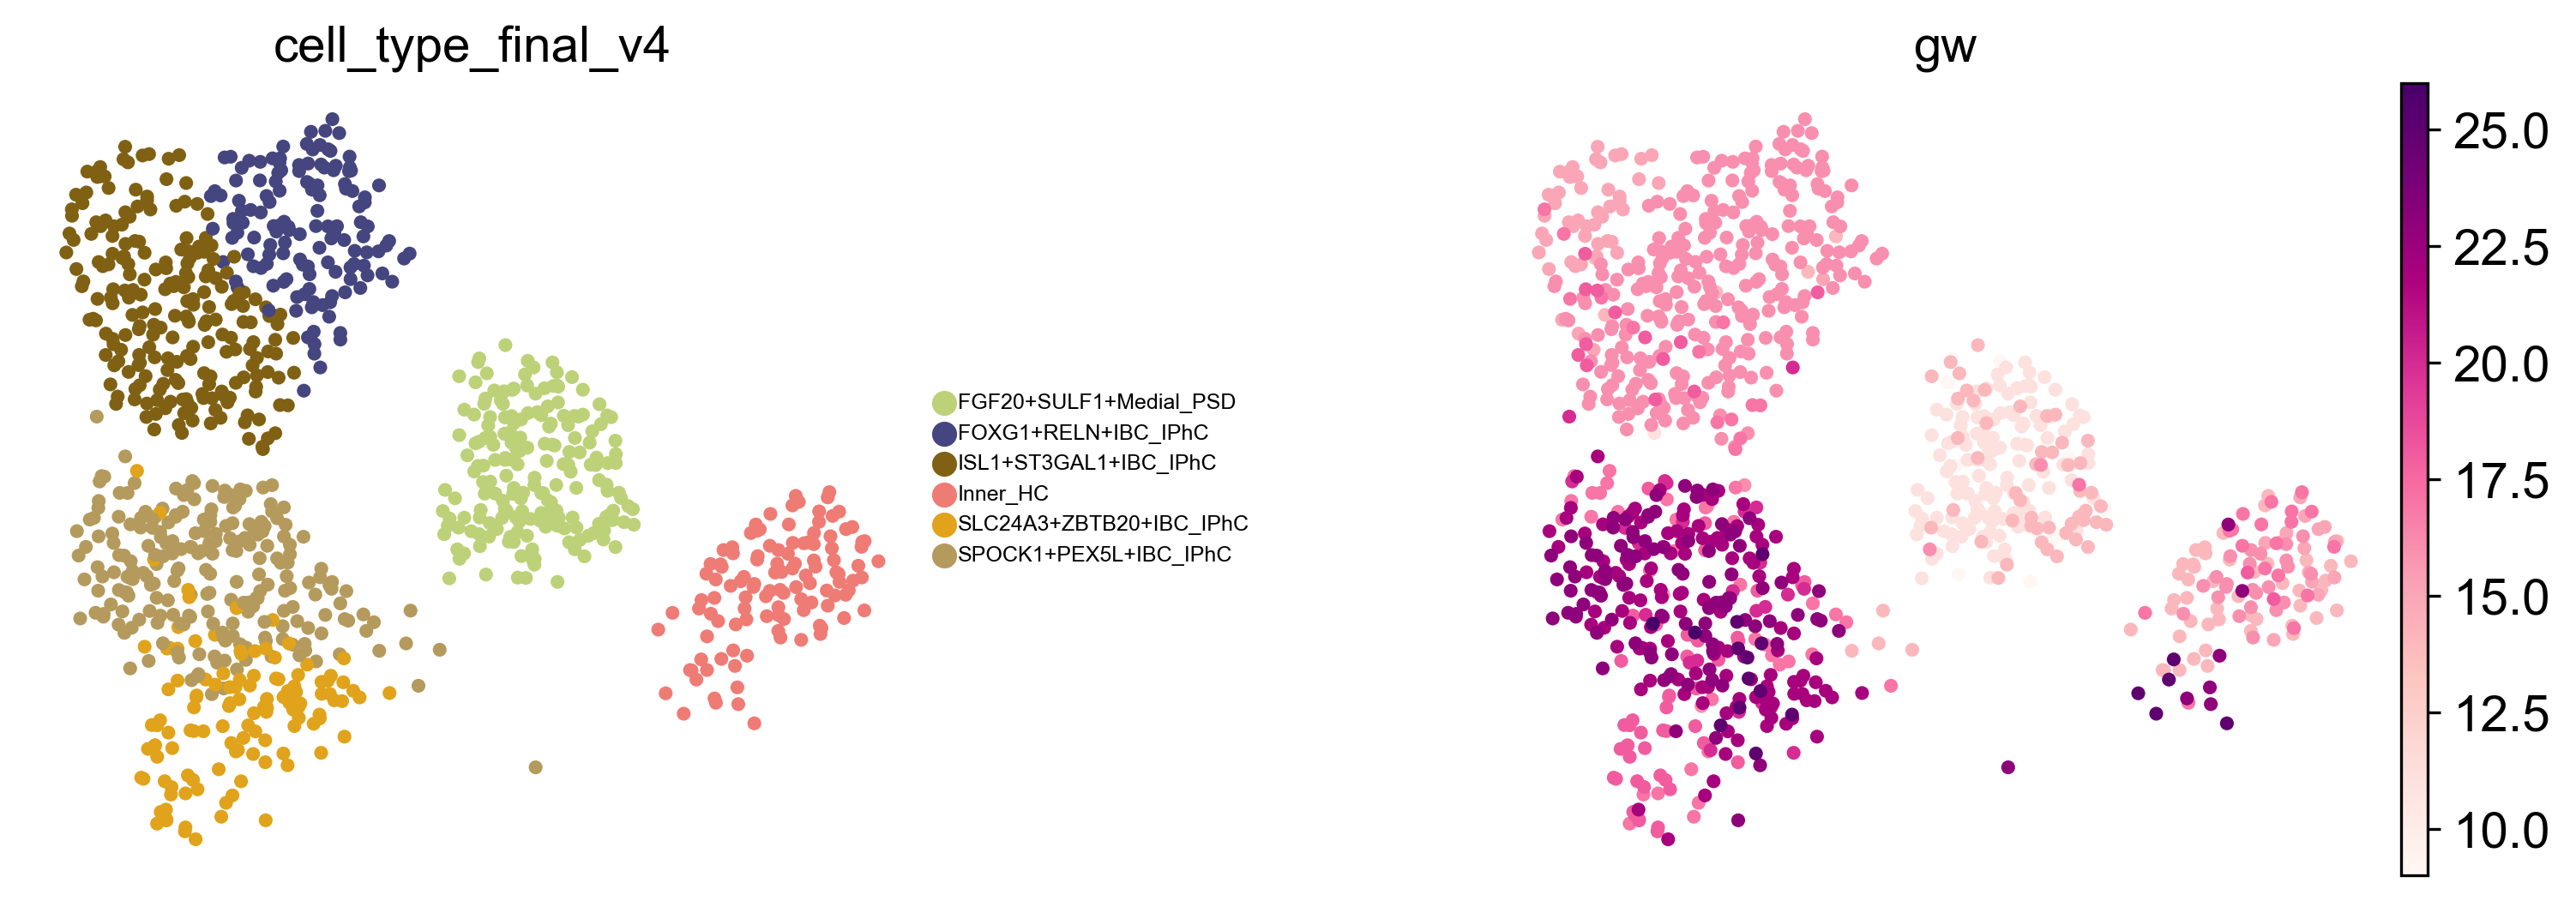

In [38]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_new_v2_inner, color=['cell_type_final_v4','gw',   
                            ],
           size=60,
           legend_fontsize=6,ncols = 2,wspace = 0.5,
           
           
          ) #color_map = 'PiYG',

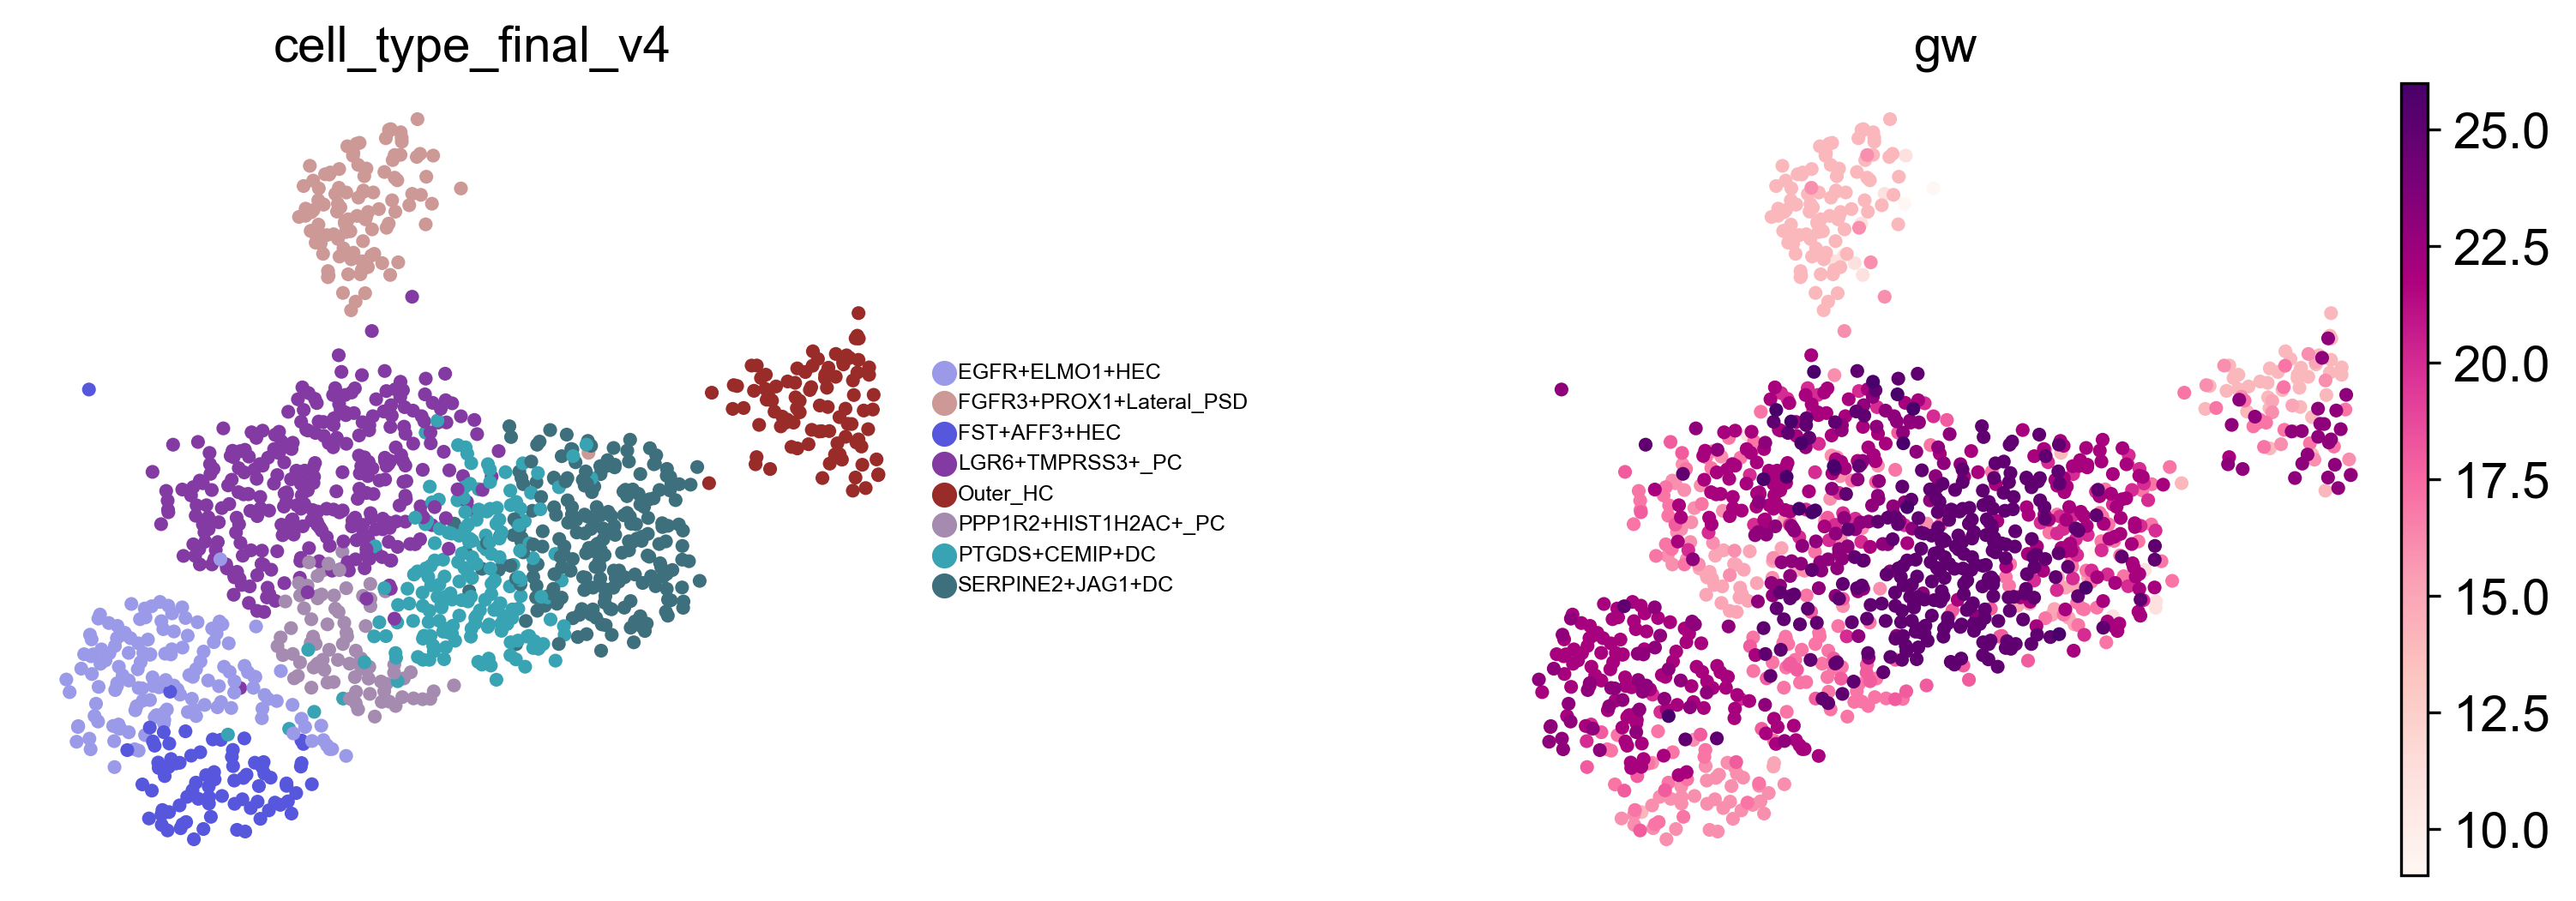

In [39]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_new_v2_outer, color=['cell_type_final_v4','gw',   
                            ],
           size=60,
           legend_fontsize=6,ncols = 2,wspace = 0.5,
           
           
          ) #color_map = 'PiYG',

In [ ]:
# export loom file and related metadata and all of it uses to load in R for Monocle2 analysis.
adata_new_v2_inner.write_loom(data_dir + 'human_coe_inner.loom')
adata_new_v2_inner.obs.to_csv(data_dir +'human_coe_inner_obs.csv')
adata_new_v2_inner.var.to_csv(data_dir +'human_coe_inner_var.csv')

In [ ]:
umap=pd.DataFrame(adata_new_v2_inner.obsm['X_umap']).to_csv(data_dir + 'human_coe_inner_umap.csv')
scANVI=pd.DataFrame(adata_new_v2_inner.obsm['X_scANVI']).to_csv(data_dir + 'human_coe_inner_scANVI.csv')

In [ ]:
# export loom file and related metadata and all of it uses to load in R for Monocle2 analysis.
adata_new_v2_outer.write_loom(data_dir + 'human_coe_outer.loom')
adata_new_v2_outer.obs.to_csv(data_dir +'human_coe_outer_obs.csv')
adata_new_v2_outer.var.to_csv(data_dir +'human_coe_outer_var.csv')

In [ ]:
umap=pd.DataFrame(adata_new_v2_outer.obsm['X_umap']).to_csv(data_dir + 'human_coe_outer_umap.csv')
scANVI=pd.DataFrame(adata_new_v2_outer.obsm['X_scANVI']).to_csv(data_dir + 'human_coe_outer_scANVI.csv')

In [41]:
adata_coe_raw.write('human_cochlea_coe_annotation_add_40000genes.h5ad',compression='gzip')

#### FIGURE 2h
##### CPDB analysis 

In [42]:
adata_coe_raw.obs['cell_type_final_v4'].value_counts()

cell_type_final_v4
LGR6+TMPRSS3+_PC           316
SPOCK1+PEX5L+IBC_IPhC      227
SERPINE2+JAG1+DC           221
ISL1+ST3GAL1+IBC_IPhC      220
PTGDS+CEMIP+DC             192
FGF20+SULF1+Medial_PSD     191
EGFR+ELMO1+HEC             142
FOXG1+RELN+IBC_IPhC        138
TBX2+MEIS2+Early_PSD       138
SLC24A3+ZBTB20+IBC_IPhC    122
Inner_HC                   116
FGFR3+PROX1+Lateral_PSD    109
Outer_HC                    94
PPP1R2+HIST1H2AC+_PC        82
FST+AFF3+HEC                80
Name: count, dtype: int64

In [46]:
import sctk as sk

G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_obj_utils.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  sc_warn = sc.logging.warn if sc.__version__.startswith("1.4") else sc.logging.warning
G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  sc_warn = sc.logging.warn if sc.__version__.startswith("1.4") else sc.logging.warning
G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_paga.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):
G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_plot.py:18: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [48]:
adata_new_sub = sk.subsample(
    adata_coe_raw, 1, groupby="cell_type_final_v4", min_n=100, max_n=100
)
adata_new_sub.obs['cell_type_final_v4'].value_counts()

cell_type_final_v4
EGFR+ELMO1+HEC             100
FGFR3+PROX1+Lateral_PSD    100
FGF20+SULF1+Medial_PSD     100
FOXG1+RELN+IBC_IPhC        100
ISL1+ST3GAL1+IBC_IPhC      100
Inner_HC                   100
LGR6+TMPRSS3+_PC           100
PTGDS+CEMIP+DC             100
SERPINE2+JAG1+DC           100
SLC24A3+ZBTB20+IBC_IPhC    100
SPOCK1+PEX5L+IBC_IPhC      100
TBX2+MEIS2+Early_PSD       100
Outer_HC                    94
PPP1R2+HIST1H2AC+_PC        82
FST+AFF3+HEC                80
Name: count, dtype: int64

In [49]:
adata_new_sub_early=adata_new_sub[adata_new_sub.obs['sample_id'].isin(['gw14','gw11','gw9'])]
adata_new_sub_late=adata_new_sub[adata_new_sub.obs['sample_id'].isin(['gw16','gw23','gw25','gw22_2','gw22_1','gw18',
                                                                     'gw17_2','gw15','gw17_1','gw20','gw17_3','gw26'])]
adata_new_sub_early=adata_new_sub_early[adata_new_sub_early.obs['cell_type_final_v4'].isin(['FGFR3+PROX1+Lateral_PSD','FGF20+SULF1+Medial_PSD',
                                                                                            'Inner_HC','Outer_HC'])]
adata_new_sub_early.obs['cell_type_final_v4'].value_counts()
adata_new_sub_late=adata_new_sub_late[adata_new_sub_late.obs['cell_type_final_v4'].isin(['EGFR+ELMO1+HEC','ISL1+ST3GAL1+IBC_IPhC',
                                                                                            'LGR6+TMPRSS3+_PC','SLC24A3+ZBTB20+IBC_IPhC',
                                                                                          'SPOCK1+PEX5L+IBC_IPhC','PTGDS+CEMIP+DC',
                                                                                          'SERPINE2+JAG1+DC','FOXG1+RELN+IBC_IPhC',
                                                                                          'PPP1R2+HIST1H2AC+_PC','FST+AFF3+HEC',
                                                                                          'Inner_HC','Outer_HC'])]
adata_new_sub_late.obs['cell_type_final_v4'].value_counts()
adata_new_sub_late_OHC_DC=adata_new_sub_late[adata_new_sub_late.obs['cell_type_final_v4'].isin([
                                                                                            
                                                                                          'PTGDS+CEMIP+DC',
                                                                                          'SERPINE2+JAG1+DC',
                                                                                          
                                                                                          'Outer_HC'])]
adata_new_sub_late_OHC_DC.obs['cell_type_final_v4'].value_counts()
adata_new_sub_late_IHC_IBC_IPH=adata_new_sub_late[adata_new_sub_late.obs['cell_type_final_v4'].isin(['ISL1+ST3GAL1+IBC_IPhC',
                                                                                           'SLC24A3+ZBTB20+IBC_IPhC',
                                                                                          'SPOCK1+PEX5L+IBC_IPhC',
                                                                                          'FOXG1+RELN+IBC_IPhC',
                                                                                          
                                                                                          'Inner_HC',])]
adata_new_sub_late_IHC_IBC_IPH.obs['cell_type_final_v4'].value_counts()
adata_new_sub_early_LPSD_MPSD=adata_new_sub_early[adata_new_sub_early.obs['cell_type_final_v4'].isin(['FGFR3+PROX1+Lateral_PSD','FGF20+SULF1+Medial_PSD',
                                                                                            ])]
adata_new_sub_early_LPSD_MPSD.obs['cell_type_final_v4'].value_counts()
adata_new_sub_early_LPSD_OHC=adata_new_sub_early[adata_new_sub_early.obs['cell_type_final_v4'].isin(['FGFR3+PROX1+Lateral_PSD',
                                                                                            'Outer_HC'
                                                                                            ])]
adata_new_sub_early_LPSD_OHC.obs['cell_type_final_v4'].value_counts()
adata_new_sub_early_MPSD_IHC=adata_new_sub_early[adata_new_sub_early.obs['cell_type_final_v4'].isin(['FGF20+SULF1+Medial_PSD',
                                                                                            'Inner_HC',
                                                                                            ])]
adata_new_sub_early_MPSD_IHC.obs['cell_type_final_v4'].value_counts()

cell_type_final_v4
FGF20+SULF1+Medial_PSD     99
FGFR3+PROX1+Lateral_PSD    97
Inner_HC                   42
Outer_HC                   41
Name: count, dtype: int64

cell_type_final_v4
EGFR+ELMO1+HEC             100
ISL1+ST3GAL1+IBC_IPhC      100
LGR6+TMPRSS3+_PC           100
SLC24A3+ZBTB20+IBC_IPhC    100
SPOCK1+PEX5L+IBC_IPhC      100
PTGDS+CEMIP+DC              99
SERPINE2+JAG1+DC            99
FOXG1+RELN+IBC_IPhC         98
PPP1R2+HIST1H2AC+_PC        82
FST+AFF3+HEC                79
Inner_HC                    58
Outer_HC                    53
Name: count, dtype: int64

cell_type_final_v4
PTGDS+CEMIP+DC      99
SERPINE2+JAG1+DC    99
Outer_HC            53
Name: count, dtype: int64

cell_type_final_v4
ISL1+ST3GAL1+IBC_IPhC      100
SLC24A3+ZBTB20+IBC_IPhC    100
SPOCK1+PEX5L+IBC_IPhC      100
FOXG1+RELN+IBC_IPhC         98
Inner_HC                    58
Name: count, dtype: int64

cell_type_final_v4
FGF20+SULF1+Medial_PSD     99
FGFR3+PROX1+Lateral_PSD    97
Name: count, dtype: int64

cell_type_final_v4
FGFR3+PROX1+Lateral_PSD    97
Outer_HC                   41
Name: count, dtype: int64

cell_type_final_v4
FGF20+SULF1+Medial_PSD    99
Inner_HC                  42
Name: count, dtype: int64

In [ ]:
#sc.pp.filter_cells(adata_new_sub, min_genes=200)
#sc.pp.filter_genes(adata_new_sub, min_cells=3)
adata_early_MPSD_IHC=sc.AnnData(adata_new_sub_early_MPSD_IHC.X,obs=pd.DataFrame(index=adata_new_sub_early_MPSD_IHC.obs.index), 
                                var=pd.DataFrame(index=adata_new_sub_early_MPSD_IHC.var.index))
adata_early_MPSD_IHC.write(data_dir+f'cpdb/norm_log_MPSD_IHC.h5ad',compression='gzip')

adata_early_LPSD_OHC=sc.AnnData(adata_new_sub_early_LPSD_OHC.X,obs=pd.DataFrame(index=adata_new_sub_early_LPSD_OHC.obs.index), 
                                var=pd.DataFrame(index=adata_new_sub_early_LPSD_OHC.var.index))
adata_early_LPSD_OHC.write(data_dir+f'cpdb/norm_log_LPSD_OHC.h5ad',compression='gzip')

adata_early_LPSD_MPSD=sc.AnnData(adata_new_sub_early_LPSD_MPSD.X,obs=pd.DataFrame(index=adata_new_sub_early_LPSD_MPSD.obs.index), 
                                var=pd.DataFrame(index=adata_new_sub_early_LPSD_MPSD.var.index))
adata_early_LPSD_MPSD.write(data_dir+f'cpdb/norm_log_LPSD_MPSD.h5ad',compression='gzip')

adata_late_IHC_IBC_IPH=sc.AnnData(adata_new_sub_late_IHC_IBC_IPH.X,obs=pd.DataFrame(index=adata_new_sub_late_IHC_IBC_IPH.obs.index), 
                                var=pd.DataFrame(index=adata_new_sub_late_IHC_IBC_IPH.var.index))
adata_late_IHC_IBC_IPH.write(data_dir+f'cpdb/norm_log_IHC_IBC_IPH.h5ad',compression='gzip')

adata_late_OHC_DC=sc.AnnData(adata_new_sub_late_OHC_DC.X,obs=pd.DataFrame(index=adata_new_sub_late_OHC_DC.obs.index), 
                                var=pd.DataFrame(index=adata_new_sub_late_OHC_DC.var.index))
adata_late_OHC_DC.write(data_dir+f'cpdb/norm_log_OHC_DC.h5ad',compression='gzip')

In [ ]:
#meta导出
df_meta = pd.DataFrame(data={'Cell':list(adata_new_sub_early_MPSD_IHC[adata_early_MPSD_IHC.obs.index].obs.index),
                             'cell_type':[ i for i in adata_new_sub_early_MPSD_IHC[adata_early_MPSD_IHC.obs.index].obs['cell_type_final_v4']]
                            })
df_meta.set_index('Cell', inplace=True)
df_meta.to_csv(data_dir+f'cpdb/meta_MPSD_IHC.tsv', sep = '\t')

df_meta = pd.DataFrame(data={'Cell':list(adata_new_sub_early_LPSD_OHC[adata_early_LPSD_OHC.obs.index].obs.index),
                             'cell_type':[ i for i in adata_new_sub_early_LPSD_OHC[adata_early_LPSD_OHC.obs.index].obs['cell_type_final_v4']]
                            })
df_meta.set_index('Cell', inplace=True)
df_meta.to_csv(data_dir+f'cpdb/meta_LPSD_OHC.tsv', sep = '\t')

df_meta = pd.DataFrame(data={'Cell':list(adata_new_sub_early_LPSD_MPSD[adata_early_LPSD_MPSD.obs.index].obs.index),
                             'cell_type':[ i for i in adata_new_sub_early_LPSD_MPSD[adata_early_LPSD_MPSD.obs.index].obs['cell_type_final_v4']]
                            })
df_meta.set_index('Cell', inplace=True)
df_meta.to_csv(data_dir+f'cpdb/meta_LPSD_MPSD.tsv', sep = '\t')

df_meta = pd.DataFrame(data={'Cell':list(adata_new_sub_late_IHC_IBC_IPH[adata_late_IHC_IBC_IPH.obs.index].obs.index),
                             'cell_type':[ i for i in adata_new_sub_late_IHC_IBC_IPH[adata_late_IHC_IBC_IPH.obs.index].obs['cell_type_final_v4']]
                            })
df_meta.set_index('Cell', inplace=True)
df_meta.to_csv(data_dir+f'cpdb/meta_IHC_IBC_IPH.tsv', sep = '\t')

df_meta = pd.DataFrame(data={'Cell':list(adata_new_sub_late_OHC_DC[adata_late_OHC_DC.obs.index].obs.index),
                             'cell_type':[ i for i in adata_new_sub_late_OHC_DC[adata_late_OHC_DC.obs.index].obs['cell_type_final_v4']]
                            })
df_meta.set_index('Cell', inplace=True)
df_meta.to_csv(data_dir+f'cpdb/meta_OHC_DC.tsv', sep = '\t')

In [ ]:
from IPython.display import HTML, display
from cellphonedb.utils import db_releases_utils

display(HTML(db_releases_utils.get_remote_database_versions_html()['db_releases_html_table']))

In [ ]:
# -- Version of the databse
cpdb_version = 'v5.0.0'

# -- Path where the input files to generate the database are located
cpdb_target_dir = os.path.join(data_dir, cpdb_version)

In [ ]:
from cellphonedb.utils import db_utils

db_utils.download_database(cpdb_target_dir, cpdb_version)

In [51]:
# EARLY LPSD-MPSD
cpdb_file_path =  data_dir+f'v5.0.0/cellphonedb.zip'
meta_file_path = data_dir+f'cpdb/meta_LPSD_MPSD.tsv'
counts_file_path = data_dir+f'cpdb/norm_log_LPSD_MPSD.h5ad'
microenvs_file_path = None
active_tf_path = None
out_path =data_dir+f'cpdb/test_cellphone_LPSD_MPSD'

In [ ]:
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method

cpdb_results = cpdb_statistical_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                 # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                 # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,             # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    counts_data = 'hgnc_symbol',                     # defines the gene annotation in counts matrix.
    active_tfs_file_path = active_tf_path,           # optional: defines cell types and their active TFs.
    microenvs_file_path = microenvs_file_path,       # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                       # optional: whether to score interactions or not. 
    iterations = 1000,                               # denotes the number of shufflings performed in the analysis.
    threshold = 0.1,                                 # defines the min % of cells expressing a gene for this to be employed in the analysis.
    threads = 10,                                     # number of threads to use in the analysis.
    debug_seed = 42,                                 # debug randome seed. To disable >=0.
    result_precision = 3,                            # Sets the rounding for the mean values in significan_means.
    pvalue = 0.01,                                   # P-value threshold to employ for significance.
    subsampling = False,                             # To enable subsampling the data (geometri sketching).
    subsampling_log = False,                         # (mandatory) enable subsampling log1p for non log-transformed data inputs.
    subsampling_num_pc = 100,                        # Number of componets to subsample via geometric skectching (dafault: 100).
    subsampling_num_cells = 1000,                    # Number of cells to subsample (integer) (default: 1/3 of the dataset).
    separator = '|',                                 # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                   # Saves all intermediate tables employed during the analysis in pkl format.
    output_path = out_path,                          # Path to save results.
    output_suffix = None                             # Replaces the timestamp in the output files by a user defined string in the  (default: None).
    )

In [56]:
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt

from pathlib import Path

#### Prepare input
##### https://ktplotspy.readthedocs.io/en/latest/notebooks/tutorial.html#
##### We will need 3 files to use this package, the h5ad file used for CellPhoneDB,the means.txt, pvalues.txt. deconvoluted.txt is only used for plot_cpdb_chord.

In [57]:
# read in the files
# 1) .h5ad file used for performing CellPhoneDB
adata_new_sub_early_LPSD_MPSD

# 2) output from CellPhoneDB
means = pd.read_csv(data_dir+f"cpdb/test_cellphone_LPSD_MPSD/statistical_analysis_means_01_13_2025_183308.txt", sep="\t")
pvals = pd.read_csv(data_dir+f"cpdb/test_cellphone_LPSD_MPSD/statistical_analysis_pvalues_01_13_2025_183308.txt", sep="\t")
decon = pd.read_csv(data_dir+f"cpdb/test_cellphone_LPSD_MPSD/statistical_analysis_deconvoluted_01_13_2025_183308.txt", sep="\t")

View of AnnData object with n_obs × n_vars = 196 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'species', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'cell_type_final', 'low_ncounts', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'is_doublet_scrub', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_res2.0', 'cell_type_final_v4'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'h

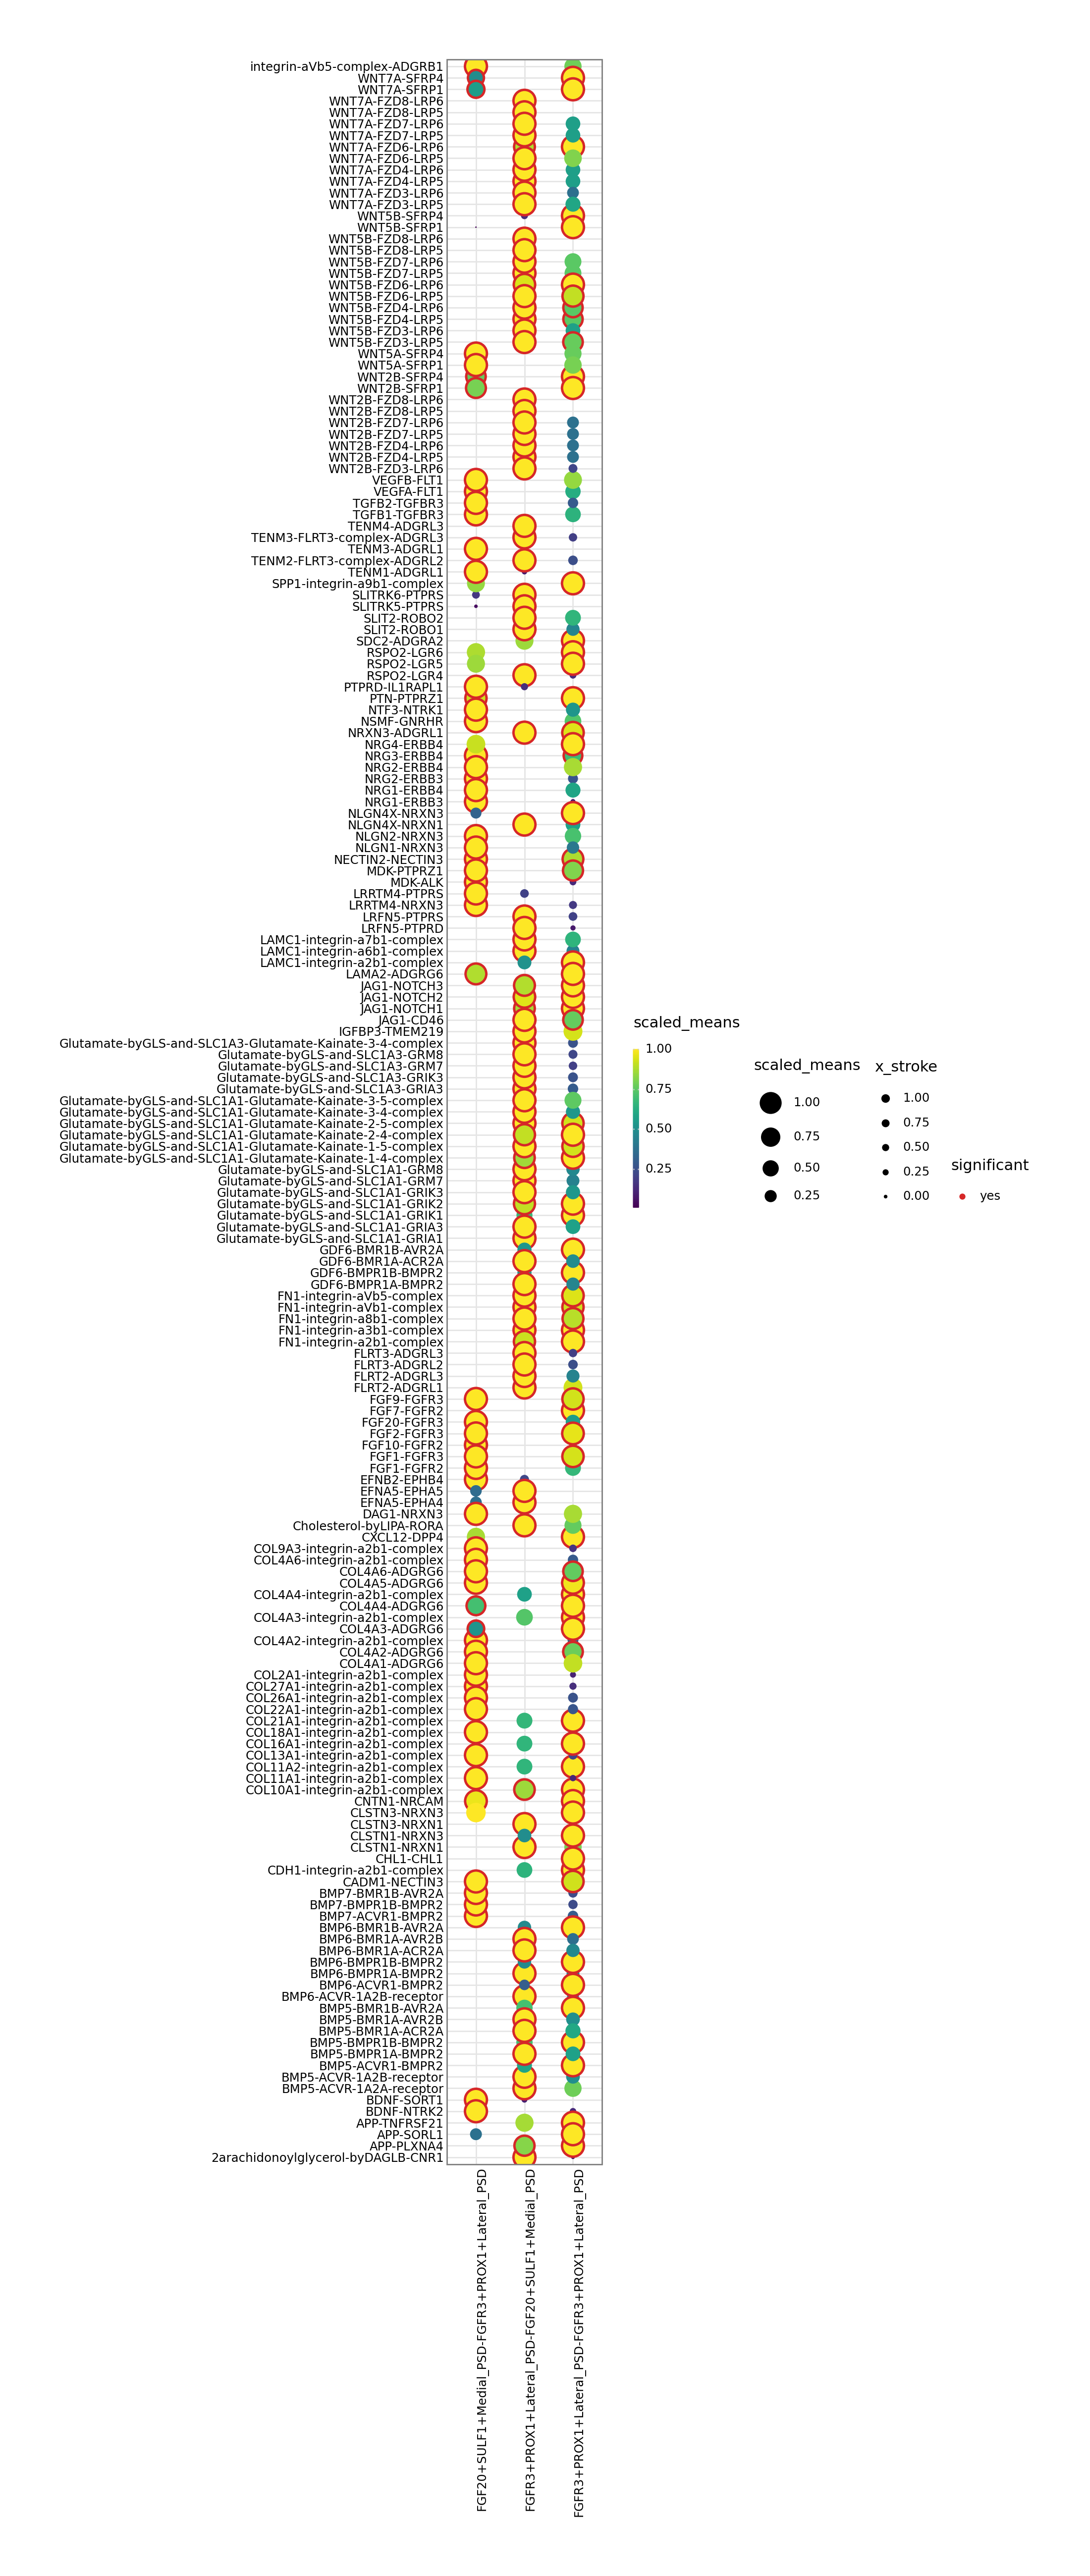

In [64]:
p=kpy.plot_cpdb(
    adata=adata_new_sub_early_LPSD_MPSD,
    cell_type1="FGFR3+PROX1+Lateral_PSD",
    cell_type2=".",
    means=means,
    pvals=pvals,
    celltype_key="cell_type_final_v4",
    highlight_size=1,
    figsize=(10, 25),
)
p
p.save(data_dir+'figures/figure2/cellphonedb_LPSD_MPSD.pdf',limitsize=False)

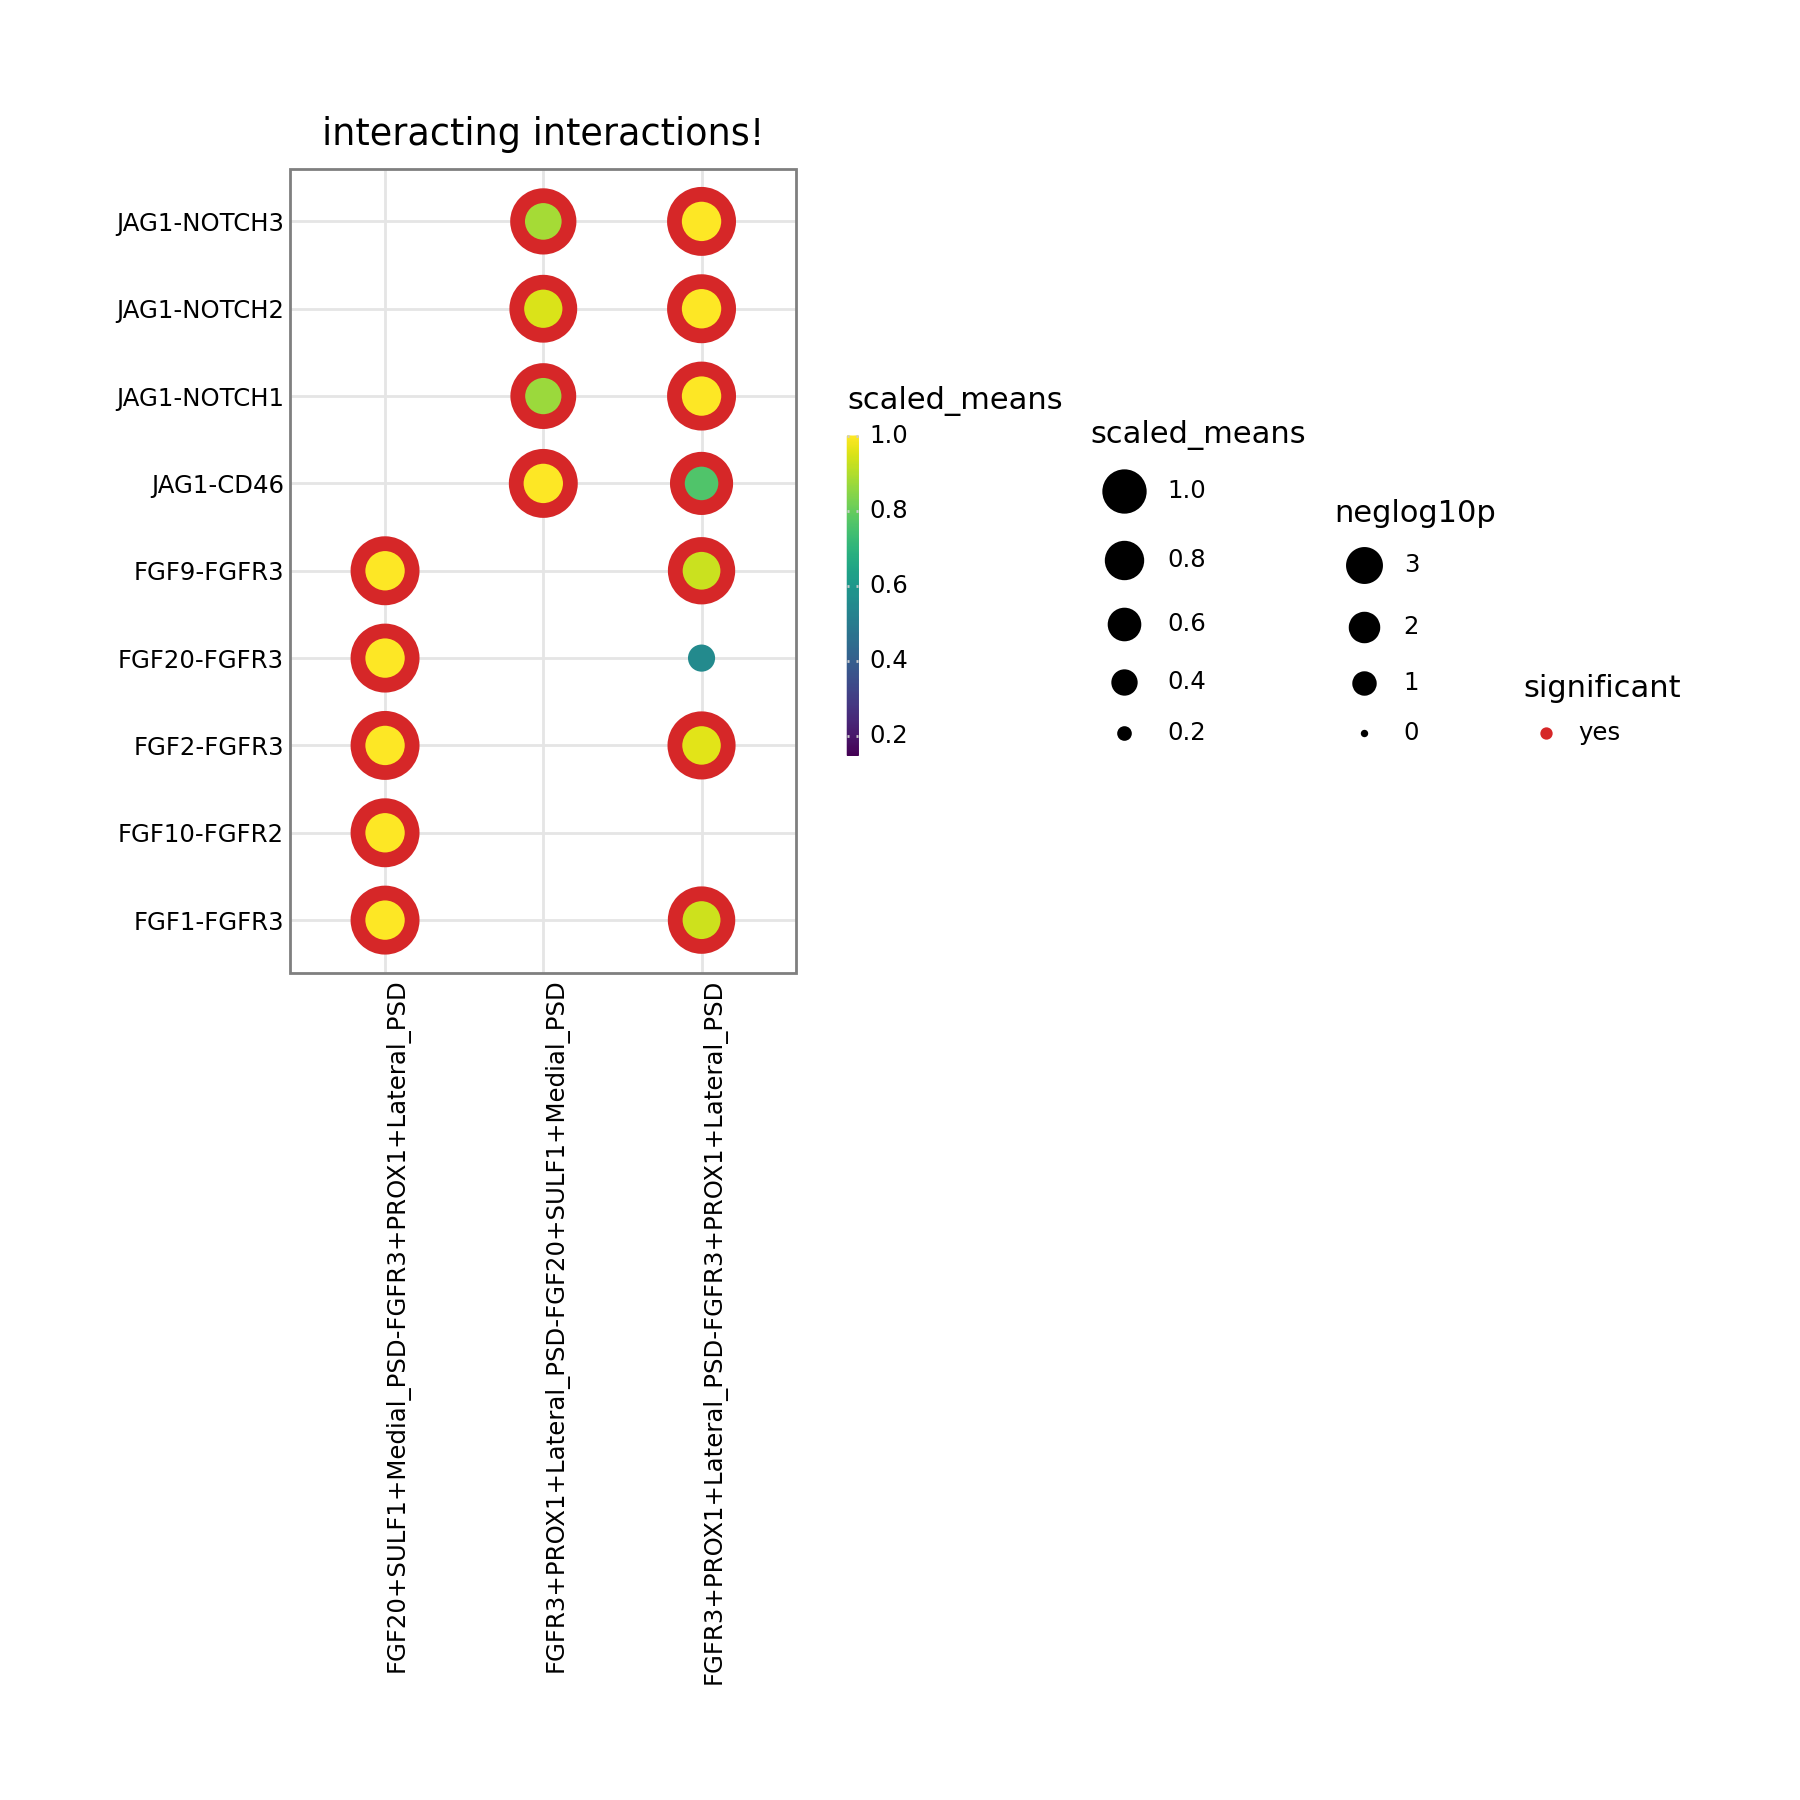

In [61]:
# TODO: How to specify the default plot resolution??
P=kpy.plot_cpdb(
    adata=adata_new_sub_early_LPSD_MPSD,
    cell_type1="FGFR3+PROX1+Lateral_PSD",#FGFR3+PROX1+Lateral_PSD
    cell_type2=".",  # this means all cell-types
    means=means,
    pvals=pvals,
    celltype_key="cell_type_final_v4",
    genes=["JAG1",'FGF10','FGF8','FGFR3',],
    figsize=(8,8),
    title="interacting interactions!",
)
P
P.save(data_dir+'figures/figure2/CPDB_SELECTED_MPSD_LPSD.pdf')

In [65]:
# read in the files
# 1) .h5ad file used for performing CellPhoneDB
adata_new_sub_early_LPSD_OHC

# 2) output from CellPhoneDB
means = pd.read_csv(data_dir+f"cpdb/test_cellphone_LPSD_OHC/statistical_analysis_means_01_26_2025_100353.txt", sep="\t")
pvals = pd.read_csv(data_dir+f"cpdb/test_cellphone_LPSD_OHC/statistical_analysis_pvalues_01_26_2025_100353.txt", sep="\t")
decon = pd.read_csv(data_dir+f"cpdb/test_cellphone_LPSD_OHC/statistical_analysis_deconvoluted_01_26_2025_100353.txt", sep="\t")

View of AnnData object with n_obs × n_vars = 138 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'species', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'cell_type_final', 'low_ncounts', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'is_doublet_scrub', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_res2.0', 'cell_type_final_v4'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'h

In [ ]:
p=kpy.plot_cpdb(
    adata=adata_new_sub_early_LPSD_OHC,
    cell_type1="Outer_HC",
    cell_type2=".",
    means=means,
    pvals=pvals,
    celltype_key="cell_type_final_v4",
    highlight_size=1,
    figsize=(15, 25),
)
p
p.save(data_dir+'figures/figure2/cellphonedb_LPSD_OHC.pdf',limitsize=False)

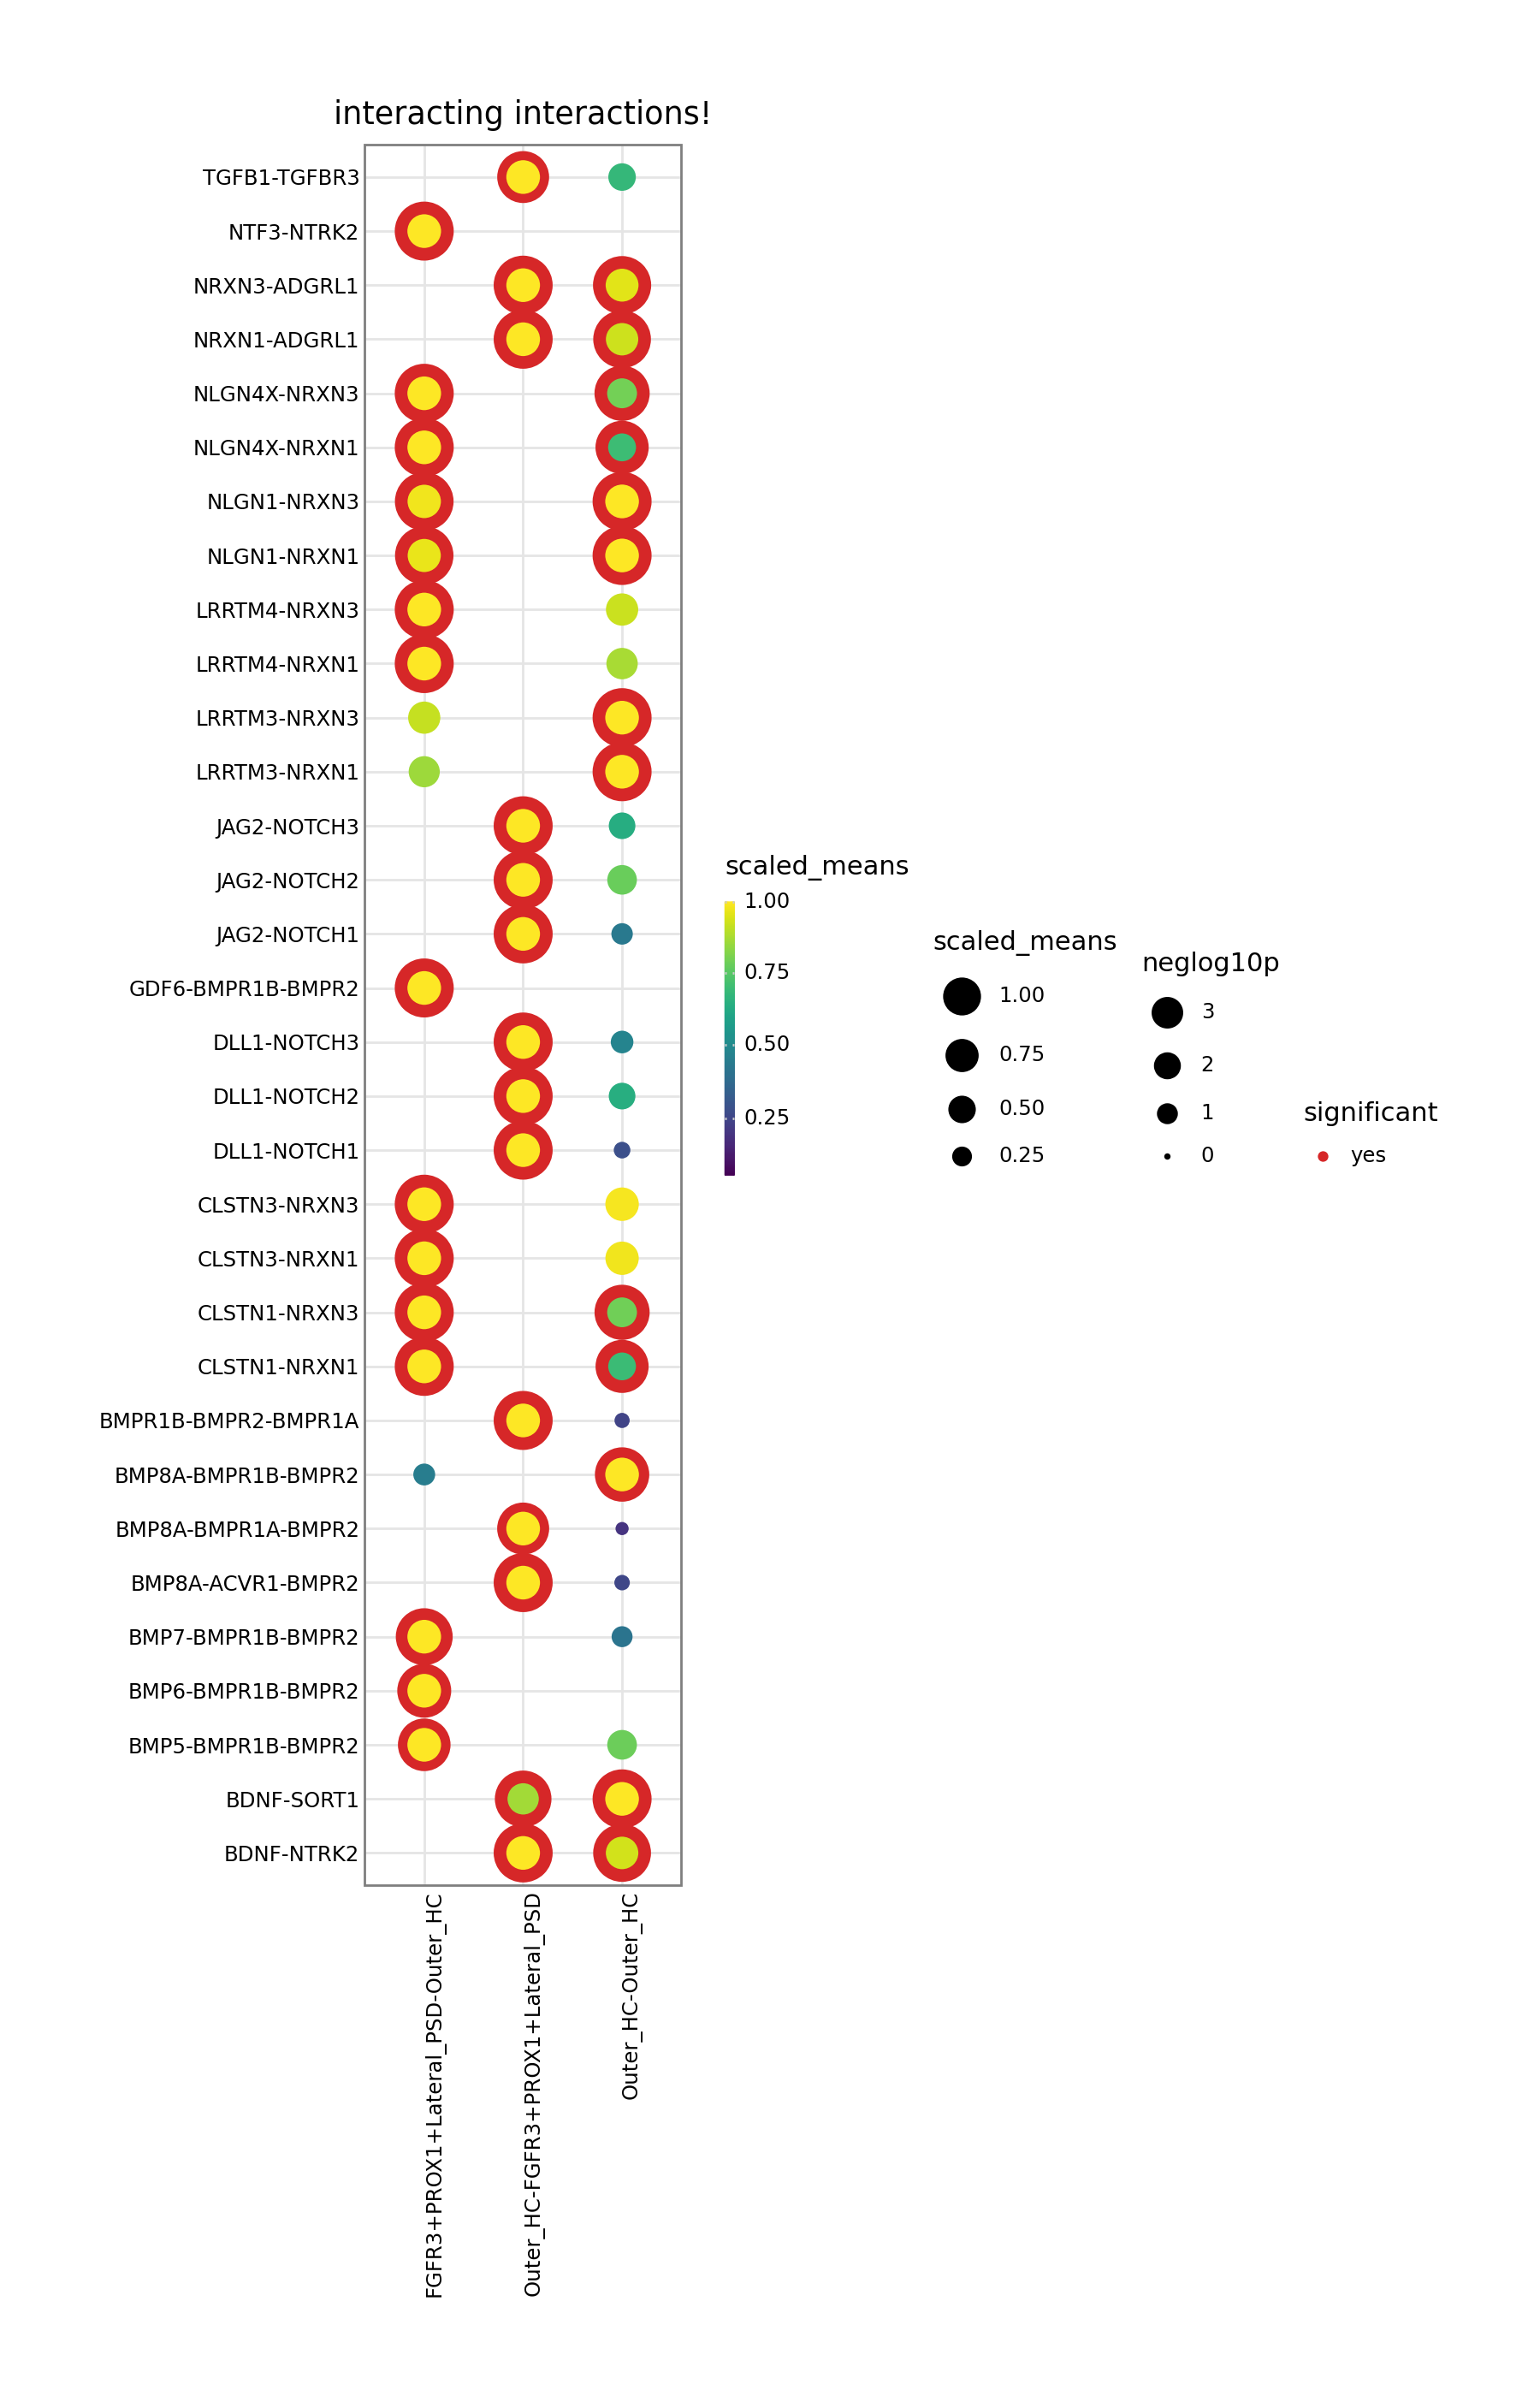

In [66]:
# TODO: How to specify the default plot resolution??
P=kpy.plot_cpdb(
    adata=adata_new_sub_early_LPSD_OHC,
    cell_type1="Outer_HC",#FGFR3+PROX1+Lateral_PSD
    cell_type2=".",  # this means all cell-types
    means=means,
    pvals=pvals,
    celltype_key="cell_type_final_v4",
    genes=["DLL1",'JAG2','TGFB1','NRXN1','NRXN3','BMPR2','BDNF','NTF3'],
    figsize=(8,13),
    title="interacting interactions!",
)
P
P.save(data_dir+'figures/figure2/CPDB_SELECTE_LPSD_OHC.pdf')

In [67]:
# read in the files
# 1) .h5ad file used for performing CellPhoneDB
adata_new_sub_early_MPSD_IHC

# 2) output from CellPhoneDB
means = pd.read_csv(data_dir+f"cpdb/test_cellphone_MPSD_IHC/statistical_analysis_means_01_13_2025_194733.txt", sep="\t")
pvals = pd.read_csv(data_dir+f"cpdb/test_cellphone_MPSD_IHC/statistical_analysis_pvalues_01_13_2025_194733.txt", sep="\t")
decon = pd.read_csv(data_dir+f"cpdb/test_cellphone_MPSD_IHC/statistical_analysis_deconvoluted_01_13_2025_194733.txt", sep="\t")

View of AnnData object with n_obs × n_vars = 141 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'species', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'cell_type_final', 'low_ncounts', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'is_doublet_scrub', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_res2.0', 'cell_type_final_v4'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'h

In [ ]:
p=kpy.plot_cpdb(
    adata=adata_new_sub_early_MPSD_IHC,
    cell_type1="Inner_HC",
    cell_type2=".",
    means=means,
    pvals=pvals,
    celltype_key="cell_type_final_v4",
    highlight_size=1,
    figsize=(15, 30),
)
p
p.save(data_dir+'figures/figure2/cellphonedb_MPSD_IHC.pdf',limitsize=False)

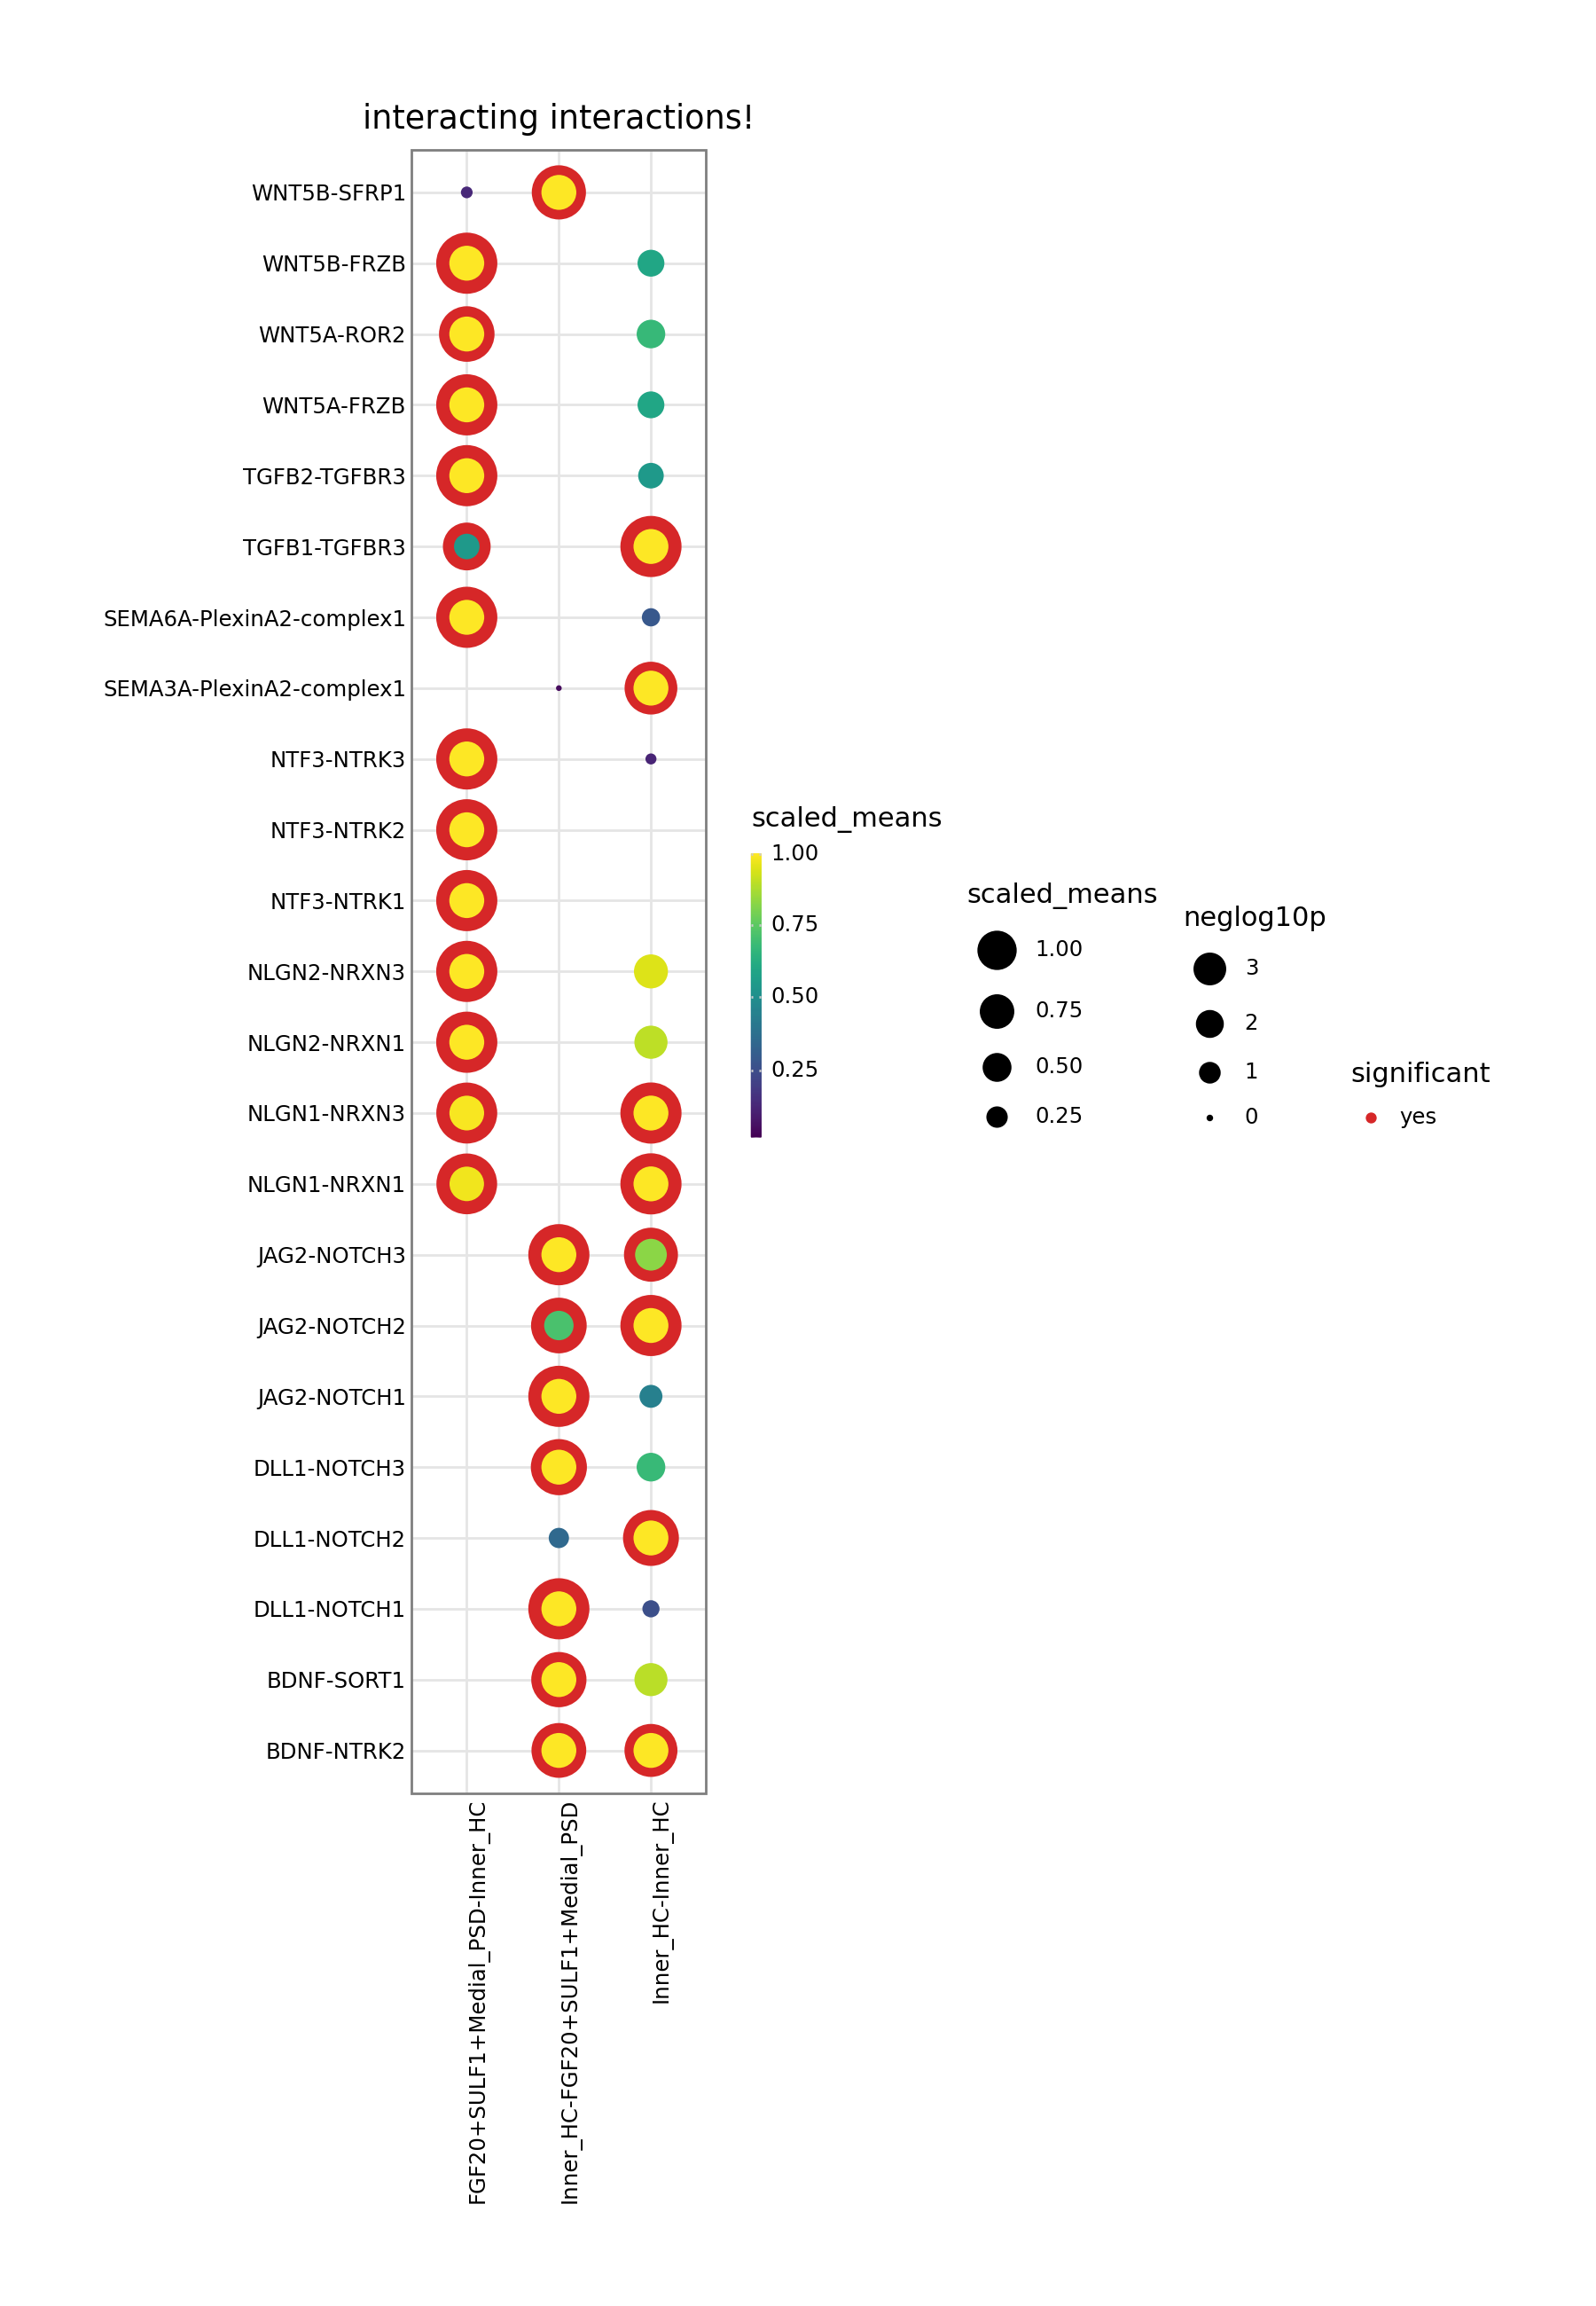

In [68]:
# TODO: How to specify the default plot resolution??
P=kpy.plot_cpdb(
    adata=adata_new_sub_early_MPSD_IHC,
    cell_type1="Inner_HC",#FGFR3+PROX1+Lateral_PSD
    cell_type2=".",  # this means all cell-types
    means=means,
    pvals=pvals,
    celltype_key="cell_type_final_v4",
    genes=["DLL1",'JAG2','BDNF','NTF3','NLGN1','NLGN2',
          'SEMA6A','SEMA3A','TGFB1','TGFB2','WNT5A','WNT5B'],
    figsize=(8,12),
    title="interacting interactions!",
)
P
P.save(data_dir+'figures/figure2/CPDB_SELECTE_MPSD_IHC.pdf')